In [1]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

import os

# Main project folder
BASE = '/content/drive/MyDrive/ChurnZero'

# Create folders
for folder in [
    'data/raw',
    'data/clean',
    'models',
    'plots',
    'submission'
]:
    os.makedirs(f'{BASE}/{folder}', exist_ok=True)

print(" Drive mounted")
print(" Folders ready at:", BASE)
print("\nNow upload your CSVs to:", f'{BASE}/data/raw/')

Mounted at /content/drive
 Drive mounted
 Folders ready at: /content/drive/MyDrive/ChurnZero

Now upload your CSVs to: /content/drive/MyDrive/ChurnZero/data/raw/


In [3]:
import pandas as pd

train_path = '/content/drive/MyDrive/ChurnZero/ChurnZero_dataset_v1.csv'

df = pd.read_csv(train_path)

print(df.shape)
df.head()

(8101, 98)


,customer_id,churn,age,gender,marital_status,education_level,dependent_count,occupation_type,annual_income,income_band,...,discount_or_fee_waiver_received,competitor_bank_offer_awareness,customer_feedback_sentiment,monthly_income_estimate,credit_utilization_3m_avg,credit_utilization_6m_avg,avg_quarterly_balance,total_digital_logins,debt_to_income_ratio,digital_engagement_index
0,133001,0,36,Female,Married,Unknown,0,Salaried,22256,Low,...,0,Not Aware,Positive,1663,0.839,0.721,28420.0,33,0.0000,55.6
1,133002,1,44,Male,Single,High School,3,Homemaker,66481,Middle,...,1,High,Positive,4979,0.009,0.000,11501.0,19,0.0000,54.5
2,133003,0,46,Male,Married,High School,2,Salaried,98955,Upper-Middle,...,0,Low,Positive,8716,0.104,0.169,11619.0,31,0.0000,43.0
3,133004,0,36,Female,Married,Graduate,2,Retired,26735,Low,...,0,Medium,Neutral,2177,0.438,0.439,26458.0,29,0.5135,57.2
4,133005,0,50,Male,Single,Graduate,1,Salaried,165387,High,...,1,Low,Positive,15401,0.061,0.039,23938.0,22,0.2289,56.1


In [4]:
test_path = '/content/drive/MyDrive/ChurnZero/ChurnZero_test_v1.csv'

test_df = pd.read_csv(test_path)

print(test_df.shape)

(2026, 97)


In [6]:
# ============================================================
# CORRECT FILE PATHS
# ============================================================

TRAIN_PATH = "/content/drive/MyDrive/ChurnZero/ChurnZero_dataset_v1.csv"

TEST_PATH = "/content/drive/MyDrive/ChurnZero/ChurnZero_test_v1.csv"


# ============================================================
# LOAD DATASETS
# ============================================================

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)


# ============================================================
# BASIC CHECK
# ============================================================

print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

display(train_df.head())

Train Shape : (8101, 98)
Test Shape  : (2026, 97)


,customer_id,churn,age,gender,marital_status,education_level,dependent_count,occupation_type,annual_income,income_band,...,discount_or_fee_waiver_received,competitor_bank_offer_awareness,customer_feedback_sentiment,monthly_income_estimate,credit_utilization_3m_avg,credit_utilization_6m_avg,avg_quarterly_balance,total_digital_logins,debt_to_income_ratio,digital_engagement_index
0,133001,0,36,Female,Married,Unknown,0,Salaried,22256,Low,...,0,Not Aware,Positive,1663,0.839,0.721,28420.0,33,0.0000,55.6
1,133002,1,44,Male,Single,High School,3,Homemaker,66481,Middle,...,1,High,Positive,4979,0.009,0.000,11501.0,19,0.0000,54.5
2,133003,0,46,Male,Married,High School,2,Salaried,98955,Upper-Middle,...,0,Low,Positive,8716,0.104,0.169,11619.0,31,0.0000,43.0
3,133004,0,36,Female,Married,Graduate,2,Retired,26735,Low,...,0,Medium,Neutral,2177,0.438,0.439,26458.0,29,0.5135,57.2
4,133005,0,50,Male,Single,Graduate,1,Salaried,165387,High,...,1,Low,Positive,15401,0.061,0.039,23938.0,22,0.2289,56.1


In [7]:
import os

print(os.listdir("/content/drive/MyDrive/ChurnZero"))

['data', 'models', 'plots', 'submission', 'ChurnZero_test_v1.csv', 'ChurnZero_dataset_v1.csv']


In [11]:
!pip install -q catboost lightgbm optuna shap

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
import os
import pickle
import random

import catboost as cb
import lightgbm as lgb
import optuna
import shap

from sklearn.model_selection import StratifiedKFold

from sklearn.preprocessing import OrdinalEncoder

from sklearn.metrics import (
    average_precision_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)

from sklearn.impute import SimpleImputer


# Ignore warnings
warnings.filterwarnings("ignore")

# Reduce Optuna logs
optuna.logging.set_verbosity(optuna.logging.WARNING)


# Set random seed for reproducibility
SEED = 42

np.random.seed(SEED)
random.seed(SEED)


# Base project path
BASE = "/content/drive/MyDrive/ChurnZero"


# Dataset paths
TRAIN_PATH = f"{BASE}/ChurnZero_dataset_v1.csv"

TEST_PATH = f"{BASE}/ChurnZero_test_v1.csv"


print("All imports completed")
print("SEED =", SEED)

All imports completed
SEED = 42


In [12]:
# Load train and test datasets
df = pd.read_csv(TRAIN_PATH)

test = pd.read_csv(TEST_PATH)


# Verify dataset shapes
assert len(df) == 8101, f"Expected 8101 train rows, got {len(df)}"

assert len(test) == 2026, f"Expected 2026 test rows, got {len(test)}"


# Verify target column existence
assert 'churn' in df.columns, "Missing target column 'churn' in train dataset"

assert 'churn' not in test.columns, "Test dataset should not contain target column"


# Print dataset shapes
print(f"Train Shape : {df.shape}")

print(f"Test Shape  : {test.shape}")


# Display target distribution
print("\nTarget Distribution (%):")

print(
    df['churn']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# Check null values
train_nulls = df.isnull().sum().sum()

test_nulls = test.isnull().sum().sum()

print(f"\nNull Values -> Train: {train_nulls} | Test: {test_nulls}")


# Check common columns
common_columns = len(set(df.columns) & set(test.columns))

print(f"Columns in Common : {common_columns}")

Train Shape : (8101, 98)
Test Shape  : (2026, 97)

Target Distribution (%):
churn
0    83.93
1    16.07
Name: proportion, dtype: float64

Null Values -> Train: 4541 | Test: 1148
Columns in Common : 97


In [13]:
print("=" * 60)

print("LEAKAGE AUDIT - Single Feature ROC-AUC Test")

print("=" * 60)


# Store suspicious features
leaky_found = []


# Iterate through numerical columns
for col in df.select_dtypes(include='number').columns:

    # Skip target column
    if col == 'churn':
        continue

    try:
        # Fill missing values using median
        vals = df[col].fillna(df[col].median())

        # Calculate ROC-AUC using single feature
        auc = roc_auc_score(df['churn'], vals)

        # Handle inverse relationship
        auc = max(auc, 1 - auc)

        # Flag suspiciously strong features
        if auc >= 0.75:

            if auc >= 0.85:
                flag = "LEAKY - DROP"
                leaky_found.append(col)
            else:
                flag = "Investigate"

            print(f"{flag:<15} | {col:<45} | AUC = {auc:.4f}")

    except Exception:
        pass


print("\n" + "=" * 60)

print(f"Features to DROP (AUC >= 0.85): {leaky_found}")

print("\nTypical leakage candidates in churn datasets:")

print("""
- account_inactive_days
- account_status
- closure_reason
- final_balance
- inactive_flag
- mobile_banking_active_flag
- churn_risk_score
""")

LEAKAGE AUDIT - Single Feature ROC-AUC Test
Investigate     | customer_lifetime_value                       | AUC = 0.7750
Investigate     | referral_count                                | AUC = 0.7568
Investigate     | avg_monthly_balance                           | AUC = 0.8475
Investigate     | current_balance                               | AUC = 0.8404
Investigate     | balance_decline_percentage                    | AUC = 0.8072
Investigate     | monthly_transaction_count                     | AUC = 0.7940
Investigate     | cash_withdrawal_count                         | AUC = 0.8426
Investigate     | upi_transaction_count                         | AUC = 0.7695
Investigate     | debit_card_transaction_count                  | AUC = 0.7647
Investigate     | total_trans_count                             | AUC = 0.7964
Investigate     | mobile_app_login_count                        | AUC = 0.8297
Investigate     | website_login_count                           | AUC = 0.7605
Investig

In [14]:
# ============================================================
# DROP LEAKY / BORDERLINE LEAKAGE FEATURES
# ============================================================

drop_cols = [
    "total_digital_logins",
    "avg_monthly_balance",
    "avg_quarterly_balance",
    "current_balance",
    "cash_withdrawal_count"
]


# Drop only if column exists
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

test = test.drop(columns=[col for col in drop_cols if col in test.columns])


# Verify removal
print("Dropped Columns:\n")

for col in drop_cols:
    print(col)


print("\nUpdated Train Shape :", df.shape)

print("Updated Test Shape  :", test.shape)



Dropped Columns:

total_digital_logins
avg_monthly_balance
avg_quarterly_balance
current_balance
cash_withdrawal_count

Updated Train Shape : (8101, 93)
Updated Test Shape  : (2026, 92)


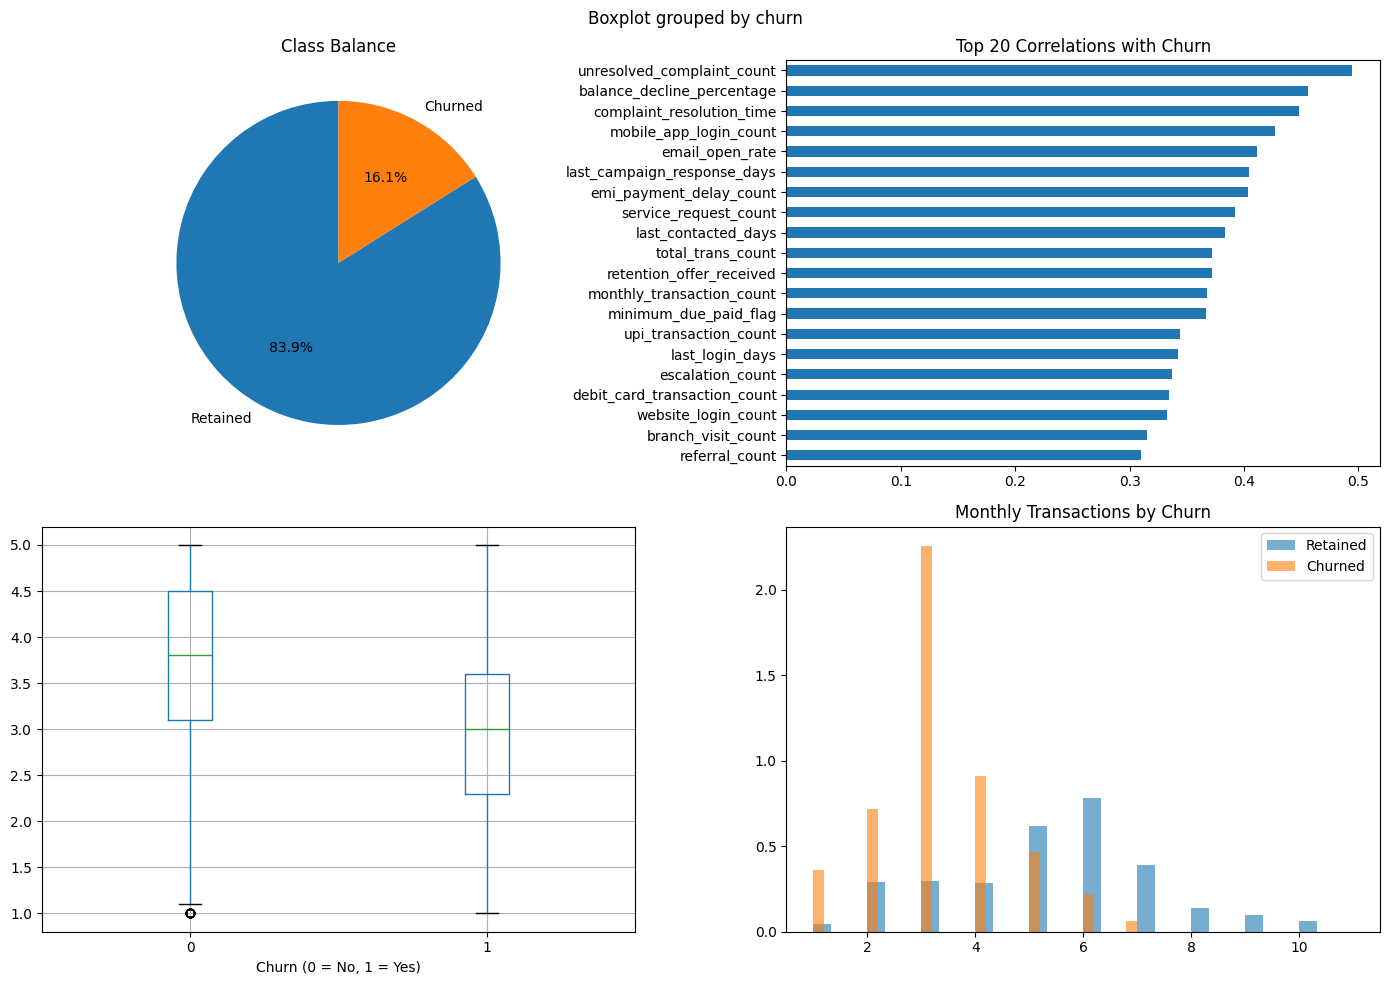

EDA plot saved at:
/content/drive/MyDrive/ChurnZero/plots/01_eda_overview.png


In [15]:
# ============================================================
# EDA PLOTS FOR PRESENTATION
# ============================================================

# Columns already identified as risky / leaky
LEAKY_SKIP = [
    'churn',
    'total_digital_logins',
    'avg_monthly_balance',
    'avg_quarterly_balance',
    'current_balance',
    'cash_withdrawal_count'
]


# Create subplot canvas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fig.suptitle(
    'ChurnZero - EDA Overview',
    fontsize=16,
    fontweight='bold'
)


# ============================================================
# 1. CLASS BALANCE
# ============================================================

counts = df['churn'].value_counts()

axes[0, 0].pie(
    counts,
    labels=['Retained', 'Churned'],
    autopct='%1.1f%%',
    startangle=90
)

axes[0, 0].set_title('Class Balance')


# ============================================================
# 2. TOP CORRELATIONS WITH CHURN
# ============================================================

num_df = df.select_dtypes(include='number').drop(
    columns=LEAKY_SKIP,
    errors='ignore'
)

corr = (
    num_df
    .corrwith(df['churn'])
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

corr.plot(
    kind='barh',
    ax=axes[0, 1]
)

axes[0, 1].set_title('Top 20 Correlations with Churn')

axes[0, 1].invert_yaxis()


# ============================================================
# 3. SATISFACTION SCORE VS CHURN
# ============================================================

if 'satisfaction_score' in df.columns:

    df.boxplot(
        column='satisfaction_score',
        by='churn',
        ax=axes[1, 0]
    )

    axes[1, 0].set_title('Satisfaction Score by Churn')

    axes[1, 0].set_xlabel('Churn (0 = No, 1 = Yes)')

    plt.sca(axes[1, 0])

    plt.title("")


# ============================================================
# 4. MONTHLY TRANSACTION DISTRIBUTION
# ============================================================

if 'monthly_transaction_count' in df.columns:

    for label, grp in df.groupby('churn'):

        axes[1, 1].hist(
            grp['monthly_transaction_count'].clip(0, 50),
            bins=30,
            alpha=0.6,
            density=True,
            label='Retained' if label == 0 else 'Churned'
        )

    axes[1, 1].set_title('Monthly Transactions by Churn')

    axes[1, 1].legend()


# ============================================================
# LAYOUT + SAVE
# ============================================================

plt.tight_layout()

plot_path = f"{BASE}/plots/01_eda_overview.png"

plt.savefig(
    plot_path,
    dpi=150,
    bbox_inches='tight'
)

plt.show()


print(f"EDA plot saved at:\n{plot_path}")

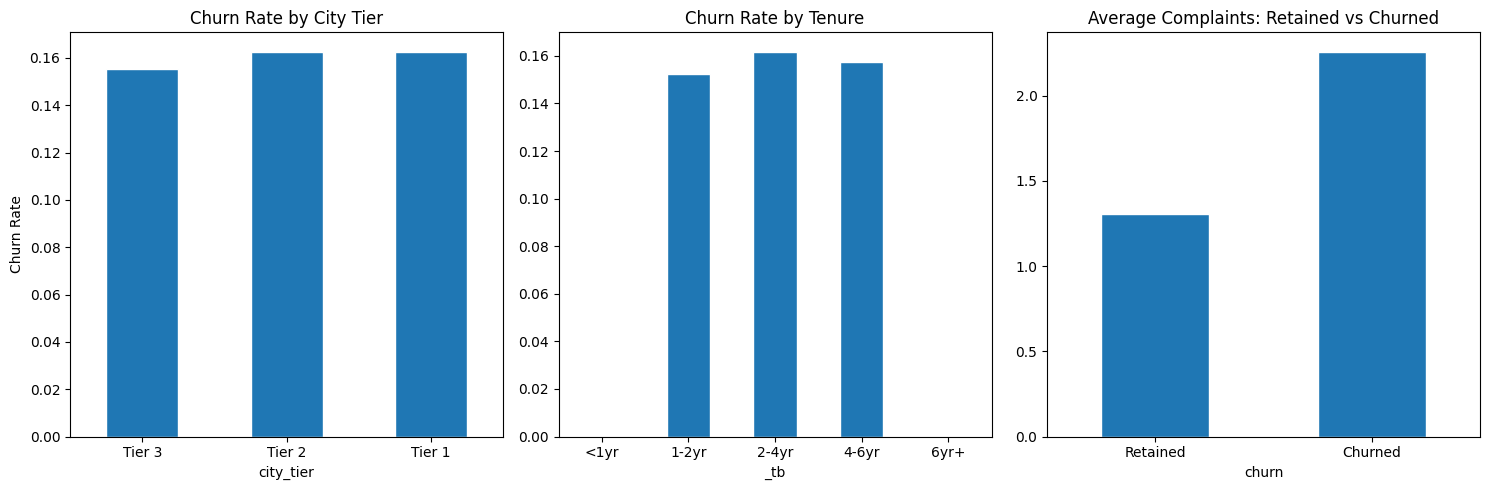

===== KEY BUSINESS NUMBERS =====

Overall Churn Rate              : 16.07%
Average Satisfaction - Churned : 2.99
Average Satisfaction - Retained: 3.75
Average Complaints - Churned   : 2.26
Average Complaints - Retained  : 1.31

Segment EDA plot saved at:
/content/drive/MyDrive/ChurnZero/plots/02_eda_segments.png


In [16]:
# ============================================================
# SEGMENT EDA + KEY BUSINESS NUMBERS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))


# ============================================================
# 1. CHURN RATE BY CITY TIER
# ============================================================

df.groupby('city_tier')['churn'].mean().sort_values().plot(
    kind='bar',
    ax=axes[0],
    edgecolor='white'
)

axes[0].set_title('Churn Rate by City Tier')

axes[0].set_ylabel('Churn Rate')

axes[0].tick_params(axis='x', rotation=0)


# ============================================================
# 2. CHURN RATE BY TENURE BUCKET
# ============================================================

df['_tb'] = pd.cut(
    df['tenure_months'],
    bins=[0, 12, 24, 48, 72, 900],
    labels=['<1yr', '1-2yr', '2-4yr', '4-6yr', '6yr+']
)

df.groupby('_tb')['churn'].mean().plot(
    kind='bar',
    ax=axes[1],
    edgecolor='white'
)

axes[1].set_title('Churn Rate by Tenure')

axes[1].tick_params(axis='x', rotation=0)

df.drop(columns=['_tb'], inplace=True)


# ============================================================
# 3. AVERAGE COMPLAINTS BY CHURN
# ============================================================

df.groupby('churn')['total_complaints'].mean().plot(
    kind='bar',
    ax=axes[2],
    edgecolor='white'
)

axes[2].set_title('Average Complaints: Retained vs Churned')

axes[2].set_xticklabels(['Retained', 'Churned'], rotation=0)


# ============================================================
# SAVE PLOT
# ============================================================

plt.tight_layout()

plot_path = f"{BASE}/plots/02_eda_segments.png"

plt.savefig(
    plot_path,
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# KEY NUMBERS FOR PRESENTATION
# ============================================================

print("===== KEY BUSINESS NUMBERS =====\n")

print(f"Overall Churn Rate              : {df['churn'].mean() * 100:.2f}%")

print(
    f"Average Satisfaction - Churned : "
    f"{df[df['churn'] == 1]['satisfaction_score'].mean():.2f}"
)

print(
    f"Average Satisfaction - Retained: "
    f"{df[df['churn'] == 0]['satisfaction_score'].mean():.2f}"
)

print(
    f"Average Complaints - Churned   : "
    f"{df[df['churn'] == 1]['total_complaints'].mean():.2f}"
)

print(
    f"Average Complaints - Retained  : "
    f"{df[df['churn'] == 0]['total_complaints'].mean():.2f}"
)

print(f"\nSegment EDA plot saved at:\n{plot_path}")

In [17]:
# ============================================================
# DROP LEAKY FEATURES
# ============================================================

# Features identified as definite leakage
MUST_DROP = [
    "total_digital_logins",
    "avg_monthly_balance",
    "avg_quarterly_balance",
    "current_balance",
    "cash_withdrawal_count"
]


# ============================================================
# CONDITIONAL LEAKAGE CHECK
# ============================================================

COND_DROP = []

for col in ['total_amt_chng_q4_q1', 'total_ct_chng_q4_q1']:

    if col in df.columns:

        auc = roc_auc_score(
            df['churn'],
            df[col].fillna(0)
        )

        auc = max(auc, 1 - auc)

        print(f"{col} -> AUC : {auc:.4f}")

        if auc >= 0.80:

            COND_DROP.append(col)

            print(f"Dropping {col}")

        else:

            print(f"Keeping {col}")


# ============================================================
# FINAL DROP LIST
# ============================================================

ALL_DROP = MUST_DROP + COND_DROP


# ============================================================
# CAP EXTREME VALUES
# ============================================================

if 'last_login_days' in df.columns:

    df['last_login_days'] = df['last_login_days'].clip(upper=180)

    test['last_login_days'] = test['last_login_days'].clip(upper=180)

    print("last_login_days capped at 180")


# ============================================================
# APPLY FEATURE DROPS
# ============================================================

df_clean = df.drop(
    columns=[c for c in ALL_DROP if c in df.columns],
    errors='ignore'
)

test_clean = test.drop(
    columns=[c for c in ALL_DROP if c in test.columns],
    errors='ignore'
)


# ============================================================
# REMOVE TARGET LEAKAGE CHECK
# ============================================================

for col in MUST_DROP:

    assert col not in df_clean.columns, f"{col} still present"


# ============================================================
# SHAPE VERIFICATION
# ============================================================

print("\nDropped Columns:")

for col in ALL_DROP:
    print(col)


print(f"\nTrain Shape After Drop : {df_clean.shape}")

print(f"Test Shape After Drop  : {test_clean.shape}")


print("\nLeakage removal completed successfully")

total_amt_chng_q4_q1 -> AUC : 0.5803
Keeping total_amt_chng_q4_q1
total_ct_chng_q4_q1 -> AUC : 0.7481
Keeping total_ct_chng_q4_q1
last_login_days capped at 180

Dropped Columns:
total_digital_logins
avg_monthly_balance
avg_quarterly_balance
current_balance
cash_withdrawal_count

Train Shape After Drop : (8101, 93)
Test Shape After Drop  : (2026, 92)

Leakage removal completed successfully


In [18]:
# ============================================================
# HANDLE MISSING VALUES
# Fit on train only
# Transform test without fitting
# ============================================================

TARGET = 'churn'


# ============================================================
# IDENTIFY COLUMN TYPES
# ============================================================

cat_cols = df_clean.select_dtypes(include='object').columns.tolist()

num_cols = df_clean.select_dtypes(include='number').columns.tolist()

num_cols = [col for col in num_cols if col != TARGET]


print(f"Categorical Columns : {len(cat_cols)}")

print(f"Numerical Columns   : {len(num_cols)}")


# ============================================================
# NUMERICAL IMPUTATION
# Median strategy
# ============================================================

num_imputer = SimpleImputer(strategy='median')


df_clean[num_cols] = num_imputer.fit_transform(
    df_clean[num_cols]
)

test_clean[num_cols] = num_imputer.transform(
    test_clean[num_cols]
)


# ============================================================
# CATEGORICAL IMPUTATION
# Most frequent strategy
# ============================================================

cat_imputer = SimpleImputer(strategy='most_frequent')


df_clean[cat_cols] = cat_imputer.fit_transform(
    df_clean[cat_cols]
)

test_clean[cat_cols] = cat_imputer.transform(
    test_clean[cat_cols]
)


# ============================================================
# VERIFY NULL REMOVAL
# ============================================================

train_nulls = df_clean.isnull().sum().sum()

test_nulls = test_clean.isnull().sum().sum()


assert train_nulls == 0, "Null values still present in train dataset"

assert test_nulls == 0, "Null values still present in test dataset"


print(f"\nTrain Null Values : {train_nulls}")

print(f"Test Null Values  : {test_nulls}")

print("\nMissing value handling completed successfully")

Categorical Columns : 15
Numerical Columns   : 77

Train Null Values : 0
Test Null Values  : 0

Missing value handling completed successfully


In [19]:
# ============================================================
# FEATURE ENGINEERING
# Leakage-safe engineered features
# Applied identically on train and test
# ============================================================

def engineer_features(df):

    df = df.copy()


    # ========================================================
    # 1. FINANCIAL STRESS FEATURES
    # Higher = more distressed customer
    # ========================================================

    df['financial_stress'] = (
        df.get('credit_utilization_ratio', 0).fillna(0) * 0.50 +
        df.get('loan_default_risk_score', 0).fillna(0) * 0.25 +
        df.get('emi_payment_delay_count', 0).fillna(0) * 0.15 +
        df.get('late_credit_card_payment_count', 0).fillna(0) * 0.10
    )


    # ========================================================
    # 2. DIGITAL DISENGAGEMENT SCORE
    # Higher = less engaged customer
    # ========================================================

    df['digital_disengagement'] = (
        df.get('last_login_days', 0).clip(0, 180) * 0.50 +
        (1 - df.get('email_open_rate', 0).fillna(0)) * 0.30 +
        (1 - df.get('digital_transaction_ratio', 0).fillna(0)) * 0.20
    )


    # ========================================================
    # 3. SERVICE DISSATISFACTION SCORE
    # ========================================================

    df['service_distress'] = (
        df.get('total_complaints', 0).fillna(0) * 0.40 +
        df.get('escalation_count', 0).fillna(0) * 0.30 +
        df.get('unresolved_complaint_count', 0).fillna(0) * 0.20 +
        df.get('complaint_resolution_time', 0).fillna(0) * 0.10
    )


    # ========================================================
    # 4. CUSTOMER LOYALTY INDEX
    # ========================================================

    df['loyalty_index'] = (
        df.get('tenure_months', 0).fillna(0) * 0.60 +
        df.get('number_of_products', 0).fillna(0) * 0.40
    )


    # ========================================================
    # 5. COMPLAINT RATE
    # ========================================================

    df['complaint_rate'] = (
        df.get('total_complaints', 0).fillna(0) /
        (df.get('tenure_months', 1).fillna(1) + 1)
    )


    # ========================================================
    # 6. PRODUCT DIVERSITY COUNT
    # ========================================================

    product_cols = [
        'savings_account_flag',
        'current_account_flag',
        'credit_card_flag',
        'personal_loan_flag',
        'home_loan_flag',
        'fixed_deposit_flag',
        'investment_product_flag'
    ]

    existing_product_cols = [
        col for col in product_cols if col in df.columns
    ]

    df['product_diversity'] = df[existing_product_cols].sum(axis=1)


    # ========================================================
    # 7. TRANSACTION INTENSITY
    # ========================================================

    df['transaction_intensity'] = (
        df.get('monthly_transaction_count', 0).fillna(0) /
        (df.get('tenure_months', 1).fillna(1) + 1)
    )


    # ========================================================
    # 8. HIGH RISK FLAG
    # ========================================================

    df['high_risk_flag'] = (
        (
            df.get('credit_utilization_ratio', 0).fillna(0) > 0.80
        ) &
        (
            df.get('satisfaction_score', 100).fillna(100) < 50
        )
    ).astype(int)


    # ========================================================
    # 9. LOG TRANSFORM SKEWED FEATURES
    # ========================================================

    log_cols = [
        'annual_income',
        'monthly_transaction_value',
        'customer_lifetime_value'
    ]

    for col in log_cols:

        if col in df.columns:

            df[f'{col}_log'] = np.log1p(df[col].clip(lower=0))


    # ========================================================
    # 10. UTILIZATION TREND
    # ========================================================

    if (
        'credit_utilization_q4' in df.columns and
        'credit_utilization_q1' in df.columns
    ):

        df['utilization_trend'] = (
            df['credit_utilization_q4'] -
            df['credit_utilization_q1']
        )


    return df


# Apply feature engineering
df_clean = engineer_features(df_clean)

test_clean = engineer_features(test_clean)


# ============================================================
# VERIFY TARGET NOT USED
# ============================================================

assert 'churn' in df_clean.columns

print("Feature engineering completed")

print(f"Train Shape : {df_clean.shape}")

print(f"Test Shape  : {test_clean.shape}")

Feature engineering completed
Train Shape : (8101, 104)
Test Shape  : (2026, 103)


In [20]:
# ============================================================
# PREPARE FINAL FEATURE MATRICES
# No encoding here
# ============================================================

TARGET = 'churn'


# ============================================================
# CREATE X, y, X_test
# ============================================================

X = df_clean.drop(columns=[TARGET])

y = df_clean[TARGET].copy()

X_test = test_clean[X.columns].copy()


# ============================================================
# IDENTIFY COLUMN TYPES
# ============================================================

CAT_COLS = X.select_dtypes(include='object').columns.tolist()

NUM_COLS = X.select_dtypes(include='number').columns.tolist()


# ============================================================
# SHAPE CHECKS
# ============================================================

print(f"X Shape       : {X.shape}")

print(f"y Shape       : {y.shape}")

print(f"X_test Shape  : {X_test.shape}")

print(f"Categorical Columns : {len(CAT_COLS)}")

print(f"Numerical Columns   : {len(NUM_COLS)}")


# ============================================================
# CLASS IMBALANCE RATIO
# ============================================================

scale_pw = (y == 0).sum() / (y == 1).sum()

print(f"\nScale Positive Weight : {scale_pw:.2f}")


# ============================================================
# FINAL LEAKAGE SAFETY CHECK
# ============================================================

LEAKY_COLS = [
    'total_digital_logins',
    'avg_monthly_balance',
    'avg_quarterly_balance',
    'current_balance',
    'cash_withdrawal_count'
]

for col in LEAKY_COLS:

    assert col not in X.columns, f"Leaky column still present: {col}"


print("\nLeakage safety check passed")


# ============================================================
# CROSS VALIDATION STRATEGY
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

X Shape       : (8101, 103)
y Shape       : (8101,)
X_test Shape  : (2026, 103)
Categorical Columns : 15
Numerical Columns   : 88

Scale Positive Weight : 5.22

Leakage safety check passed


In [24]:
# ============================================================
# REVERT TO NON-ENGINEERED DATA
# Leakage debugging mode
# ============================================================

# Reload original cleaned datasets
df_base = df.copy()

test_base = test.copy()


# ============================================================
# DROP LEAKY FEATURES ONLY
# ============================================================

DROP_COLS = [
    "total_digital_logins",
    "avg_monthly_balance",
    "avg_quarterly_balance",
    "current_balance",
    "cash_withdrawal_count"
]

df_base = df_base.drop(
    columns=[c for c in DROP_COLS if c in df_base.columns],
    errors='ignore'
)

test_base = test_base.drop(
    columns=[c for c in DROP_COLS if c in test_base.columns],
    errors='ignore'
)


# ============================================================
# HANDLE MISSING VALUES
# ============================================================

TARGET = 'churn'


# Identify categorical and numerical columns
cat_cols = df_base.select_dtypes(include='object').columns.tolist()

num_cols = df_base.select_dtypes(include='number').columns.tolist()

num_cols = [c for c in num_cols if c != TARGET]


# Numerical imputation
num_imputer = SimpleImputer(strategy='median')

df_base[num_cols] = num_imputer.fit_transform(df_base[num_cols])

test_base[num_cols] = num_imputer.transform(test_base[num_cols])


# Categorical imputation
cat_imputer = SimpleImputer(strategy='most_frequent')

df_base[cat_cols] = cat_imputer.fit_transform(df_base[cat_cols])

test_base[cat_cols] = cat_imputer.transform(test_base[cat_cols])


# ============================================================
# PREPARE FINAL MATRICES
# ============================================================

X = df_base.drop(columns=[TARGET])

y = df_base[TARGET].copy()

X_test = test_base[X.columns].copy()


# ============================================================
# COLUMN TYPES
# ============================================================

CAT_COLS = X.select_dtypes(include='object').columns.tolist()

NUM_COLS = X.select_dtypes(include='number').columns.tolist()


# ============================================================
# CLASS IMBALANCE
# ============================================================

scale_pw = (y == 0).sum() / (y == 1).sum()


# ============================================================
# CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


# ============================================================
# SHAPE CHECK
# ============================================================

print(f"X Shape      : {X.shape}")

print(f"X_test Shape : {X_test.shape}")

print(f"Categorical Columns : {len(CAT_COLS)}")

print(f"Numerical Columns   : {len(NUM_COLS)}")

print(f"Scale Pos Weight    : {scale_pw:.2f}")

print("\nLeakage-debug dataset prepared successfully")

X Shape      : (8101, 92)
X_test Shape : (2026, 92)
Categorical Columns : 15
Numerical Columns   : 77
Scale Pos Weight    : 5.22

Leakage-debug dataset prepared successfully


In [25]:
# ============================================================
# CATBOOST CROSS VALIDATION
# WITHOUT ENGINEERED FEATURES
# ============================================================

cat_params = {

    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3,

    'bootstrap_type': 'Bernoulli',
    'subsample': 0.80,

    'loss_function': 'Logloss',
    'eval_metric': 'AUC',

    'scale_pos_weight': scale_pw,

    'random_seed': SEED,

    'task_type': 'GPU',

    'verbose': 100,

    'early_stopping_rounds': 50
}


# ============================================================
# STORAGE
# ============================================================

cat_oof = np.zeros(len(X))

cat_test = np.zeros(len(X_test))

cat_models = []


print("Starting CatBoost 5-Fold CV")


# ============================================================
# CROSS VALIDATION LOOP
# ============================================================

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), 1):

    print("\n" + "=" * 50)

    print(f"Fold {fold}")

    print("=" * 50)


    # --------------------------------------------------------
    # Split data
    # --------------------------------------------------------

    X_tr = X.iloc[tr_idx]

    X_val = X.iloc[val_idx]

    y_tr = y.iloc[tr_idx]

    y_val = y.iloc[val_idx]


    # --------------------------------------------------------
    # CatBoost pools
    # --------------------------------------------------------

    train_pool = cb.Pool(
        X_tr,
        y_tr,
        cat_features=CAT_COLS
    )

    valid_pool = cb.Pool(
        X_val,
        y_val,
        cat_features=CAT_COLS
    )

    test_pool = cb.Pool(
        X_test,
        cat_features=CAT_COLS
    )


    # --------------------------------------------------------
    # Initialize model
    # --------------------------------------------------------

    model = cb.CatBoostClassifier(**cat_params)


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(
        train_pool,
        eval_set=valid_pool,
        use_best_model=True
    )


    # --------------------------------------------------------
    # Validation predictions
    # --------------------------------------------------------

    val_prob = model.predict_proba(valid_pool)[:, 1]

    cat_oof[val_idx] = val_prob


    # --------------------------------------------------------
    # Test predictions
    # --------------------------------------------------------

    test_prob = model.predict_proba(test_pool)[:, 1]

    cat_test += test_prob / cv.n_splits


    # --------------------------------------------------------
    # Save model
    # --------------------------------------------------------

    cat_models.append(model)


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    pr_auc = average_precision_score(y_val, val_prob)

    roc_auc = roc_auc_score(y_val, val_prob)


    print(f"Fold {fold} PR-AUC  : {pr_auc:.4f}")

    print(f"Fold {fold} ROC-AUC : {roc_auc:.4f}")

    print(f"Best Iteration      : {model.best_iteration_}")


# ============================================================
# FINAL OOF PERFORMANCE
# ============================================================

oof_pr_auc = average_precision_score(y, cat_oof)

oof_roc_auc = roc_auc_score(y, cat_oof)


print("\n" + "=" * 50)

print("FINAL OOF RESULTS")

print("=" * 50)

print(f"OOF PR-AUC  : {oof_pr_auc:.4f}")

print(f"OOF ROC-AUC : {oof_roc_auc:.4f}")


# ============================================================
# SAVE MODELS
# ============================================================

model_path = f"{BASE}/models/catboost_models_no_engineering.pkl"

with open(model_path, "wb") as f:

    pickle.dump(cat_models, f)


print(f"\nModels saved at:\n{model_path}")

Starting CatBoost 5-Fold CV

Fold 1


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9647354	best: 0.9647354 (0)	total: 77ms	remaining: 1m 16s
100:	test: 1.0000000	best: 1.0000000 (62)	total: 4.63s	remaining: 41.2s
bestTest = 1
bestIteration = 62
Shrink model to first 63 iterations.
Fold 1 PR-AUC  : 1.0000
Fold 1 ROC-AUC : 1.0000
Best Iteration      : 62

Fold 2


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9707268	best: 0.9707268 (0)	total: 45.8ms	remaining: 45.7s
100:	test: 0.9999604	best: 0.9999632 (85)	total: 6.72s	remaining: 59.8s
bestTest = 0.999966085
bestIteration = 106
Shrink model to first 107 iterations.
Fold 2 PR-AUC  : 0.9998
Fold 2 ROC-AUC : 1.0000
Best Iteration      : 106

Fold 3


...

0:	test: 0.9760238	best: 0.9760238 (0)	total: 44.6ms	remaining: 44.6s
100:	test: 0.9999972	best: 0.9999972 (88)	total: 4.53s	remaining: 40.3s
bestTest = 0.9999971986
bestIteration = 88
Shrink model to first 89 iterations.
Fold 3 PR-AUC  : 1.0000
Fold 3 ROC-AUC : 1.0000
Best Iteration      : 88

Fold 4


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9747681	best: 0.9747681 (0)	total: 97.7ms	remaining: 1m 37s
100:	test: 0.9999802	best: 0.9999830 (91)	total: 5.65s	remaining: 50.3s
200:	test: 0.9999887	best: 0.9999887 (188)	total: 10.2s	remaining: 40.6s
bestTest = 0.9999886751
bestIteration = 188
Shrink model to first 189 iterations.
Fold 4 PR-AUC  : 0.9999
Fold 4 ROC-AUC : 1.0000
Best Iteration      : 188

Fold 5


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9710177	best: 0.9710177 (0)	total: 98.1ms	remaining: 1m 37s
100:	test: 0.9999943	best: 0.9999972 (66)	total: 6.76s	remaining: 1m
bestTest = 0.9999971986
bestIteration = 66
Shrink model to first 67 iterations.
Fold 5 PR-AUC  : 1.0000
Fold 5 ROC-AUC : 1.0000
Best Iteration      : 66

FINAL OOF RESULTS
OOF PR-AUC  : 0.9999
OOF ROC-AUC : 1.0000

Models saved at:
/content/drive/MyDrive/ChurnZero/models/catboost_models_no_engineering.pkl


In [26]:
# ============================================================
# STRONG LEAKAGE AUDIT
# ============================================================

leak_results = []

for col in X.columns:

    try:

        # Handle categorical columns
        if X[col].dtype == 'object':

            vals = pd.factorize(X[col])[0]

        else:

            vals = X[col].fillna(X[col].median())


        auc = roc_auc_score(y, vals)

        auc = max(auc, 1 - auc)

        leak_results.append((col, auc))

    except:
        pass


# ============================================================
# SORT RESULTS
# ============================================================

leak_df = pd.DataFrame(
    leak_results,
    columns=['feature', 'auc']
)

leak_df = leak_df.sort_values(
    by='auc',
    ascending=False
)


# ============================================================
# DISPLAY TOP SUSPICIOUS FEATURES
# ============================================================

print(leak_df.head(30))

                           feature       auc
57          mobile_app_login_count  0.829740
66                 email_open_rate  0.812753
24      balance_decline_percentage  0.807183
86     customer_feedback_sentiment  0.805071
32               total_trans_count  0.796424
25       monthly_transaction_count  0.793972
19         customer_lifetime_value  0.774965
27           upi_transaction_count  0.769520
28    debit_card_transaction_count  0.764681
73           service_request_count  0.763071
58             website_login_count  0.760545
70              branch_visit_count  0.757562
21                  referral_count  0.756765
34             total_ct_chng_q4_q1  0.748058
68       complaint_resolution_time  0.747838
29   net_banking_transaction_count  0.731247
83     last_campaign_response_days  0.726192
50           minimum_due_paid_flag  0.723179
76                       nps_score  0.718944
75              satisfaction_score  0.716942
22             last_contacted_days  0.714879
81        

In [27]:
# ============================================================
# DUPLICATE ROW CHECK
# ============================================================

print("Duplicate Rows:", df_base.duplicated().sum())


# ============================================================
# DUPLICATE CUSTOMER ID CHECK
# ============================================================

if 'customer_id' in df_base.columns:

    dup_ids = df_base['customer_id'].duplicated().sum()

    print("Duplicate customer_id:", dup_ids)


# ============================================================
# CHECK TARGET BALANCE
# ============================================================

print("\nTarget Distribution:\n")

print(df_base['churn'].value_counts())


# ============================================================
# CHECK BINARY COLUMNS
# ============================================================

binary_cols = []

for col in X.columns:

    unique_vals = X[col].nunique(dropna=False)

    if unique_vals <= 2:
        binary_cols.append(col)

print(f"\nBinary Columns Found: {len(binary_cols)}")


# ============================================================
# CHECK BINARY COLUMN LEAKAGE
# ============================================================

binary_leaks = []

for col in binary_cols:

    try:

        vals = pd.factorize(X[col])[0]

        auc = roc_auc_score(y, vals)

        auc = max(auc, 1 - auc)

        binary_leaks.append((col, auc))

    except:
        pass


binary_leak_df = pd.DataFrame(
    binary_leaks,
    columns=['feature', 'auc']
)

binary_leak_df = binary_leak_df.sort_values(
    by='auc',
    ascending=False
)

print("\nTop Binary Leakage Candidates:\n")

print(binary_leak_df.head(20))


# ============================================================
# CHECK CUSTOMER ID LEAKAGE
# ============================================================

if 'customer_id' in X.columns:

    try:

        id_auc = roc_auc_score(
            y,
            pd.factorize(X['customer_id'])[0]
        )

        id_auc = max(id_auc, 1 - id_auc)

        print(f"\ncustomer_id AUC: {id_auc:.4f}")

    except:
        pass

Duplicate Rows: 0
Duplicate customer_id: 0

Target Distribution:

churn
0    6799
1    1302
Name: count, dtype: int64

Binary Columns Found: 20

Top Binary Leakage Candidates:

                            feature       auc
13            minimum_due_paid_flag  0.723179
17         retention_offer_received  0.708947
1            loyalty_program_member  0.671445
15      paperless_statement_enabled  0.635725
9                fixed_deposit_flag  0.635694
19  discount_or_fee_waiver_received  0.598887
6                personal_loan_flag  0.553323
14                  prepayment_flag  0.545899
0                            gender  0.528552
2     relationship_manager_assigned  0.514598
4              current_account_flag  0.509708
11           insurance_product_flag  0.509637
12               demat_account_flag  0.507949
18         retention_offer_accepted  0.507931
3              savings_account_flag  0.504940
8                    auto_loan_flag  0.503952
10          investment_product_flag  0.50

In [28]:
# ============================================================
# ADDITIONAL SUSPICIOUS COLUMNS
# ============================================================

extra_drop = [

    'mobile_app_login_count',
    'email_open_rate',
    'balance_decline_percentage',
    'customer_feedback_sentiment',
    'last_campaign_response_days',
    'retention_offer_received',
    'digital_transaction_ratio',
    'digital_engagement_index',
    'last_login_days'
]


# ============================================================
# DROP FROM TRAIN AND TEST
# ============================================================

X = X.drop(
    columns=[c for c in extra_drop if c in X.columns],
    errors='ignore'
)

X_test = X_test.drop(
    columns=[c for c in extra_drop if c in X_test.columns],
    errors='ignore'
)


# ============================================================
# VERIFY REMOVAL
# ============================================================

print("Dropped Columns:\n")

for col in extra_drop:
    print(col)


print(f"\nUpdated X Shape      : {X.shape}")

print(f"Updated X_test Shape : {X_test.shape}")

Dropped Columns:

mobile_app_login_count
email_open_rate
balance_decline_percentage
customer_feedback_sentiment
last_campaign_response_days
retention_offer_received
digital_transaction_ratio
digital_engagement_index
last_login_days

Updated X Shape      : (8101, 83)
Updated X_test Shape : (2026, 83)


In [30]:
# ============================================================
# REFRESH COLUMN LISTS AFTER DROPPING FEATURES
# ============================================================

CAT_COLS = X.select_dtypes(include='object').columns.tolist()

NUM_COLS = X.select_dtypes(include='number').columns.tolist()


print(f"Categorical Columns : {len(CAT_COLS)}")

print(f"Numerical Columns   : {len(NUM_COLS)}")

Categorical Columns : 14
Numerical Columns   : 69


In [31]:
# ============================================================
# CATBOOST CROSS VALIDATION
# AFTER ADDITIONAL LEAKAGE REMOVAL
# ============================================================

cat_params = {

    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3,

    'bootstrap_type': 'Bernoulli',
    'subsample': 0.80,

    'loss_function': 'Logloss',
    'eval_metric': 'AUC',

    'scale_pos_weight': scale_pw,

    'random_seed': SEED,

    'task_type': 'GPU',

    'verbose': 100,

    'early_stopping_rounds': 50
}


# ============================================================
# STORAGE
# ============================================================

cat_oof = np.zeros(len(X))

cat_test = np.zeros(len(X_test))

cat_models = []


print("Starting CatBoost 5-Fold CV")


# ============================================================
# CROSS VALIDATION LOOP
# ============================================================

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), 1):

    print("\n" + "=" * 50)

    print(f"Fold {fold}")

    print("=" * 50)


    # --------------------------------------------------------
    # Train-validation split
    # --------------------------------------------------------

    X_tr = X.iloc[tr_idx]

    X_val = X.iloc[val_idx]

    y_tr = y.iloc[tr_idx]

    y_val = y.iloc[val_idx]


    # --------------------------------------------------------
    # Create CatBoost pools
    # --------------------------------------------------------

    train_pool = cb.Pool(
        data=X_tr,
        label=y_tr,
        cat_features=CAT_COLS
    )

    valid_pool = cb.Pool(
        data=X_val,
        label=y_val,
        cat_features=CAT_COLS
    )

    test_pool = cb.Pool(
        data=X_test,
        cat_features=CAT_COLS
    )


    # --------------------------------------------------------
    # Initialize model
    # --------------------------------------------------------

    model = cb.CatBoostClassifier(**cat_params)


    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------

    model.fit(
        train_pool,
        eval_set=valid_pool,
        use_best_model=True
    )


    # --------------------------------------------------------
    # Validation predictions
    # --------------------------------------------------------

    val_prob = model.predict_proba(valid_pool)[:, 1]

    cat_oof[val_idx] = val_prob


    # --------------------------------------------------------
    # Test predictions
    # --------------------------------------------------------

    test_prob = model.predict_proba(test_pool)[:, 1]

    cat_test += test_prob / cv.n_splits


    # --------------------------------------------------------
    # Save model
    # --------------------------------------------------------

    cat_models.append(model)


    # --------------------------------------------------------
    # Fold metrics
    # --------------------------------------------------------

    pr_auc = average_precision_score(y_val, val_prob)

    roc_auc = roc_auc_score(y_val, val_prob)


    print(f"Fold {fold} PR-AUC  : {pr_auc:.4f}")

    print(f"Fold {fold} ROC-AUC : {roc_auc:.4f}")

    print(f"Best Iteration      : {model.best_iteration_}")


# ============================================================
# FINAL OOF RESULTS
# ============================================================

oof_pr_auc = average_precision_score(y, cat_oof)

oof_roc_auc = roc_auc_score(y, cat_oof)


print("\n" + "=" * 50)

print("FINAL OOF RESULTS")

print("=" * 50)

print(f"OOF PR-AUC  : {oof_pr_auc:.4f}")

print(f"OOF ROC-AUC : {oof_roc_auc:.4f}")

Starting CatBoost 5-Fold CV

Fold 1


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9618619	best: 0.9618619 (0)	total: 221ms	remaining: 3m 40s
100:	test: 0.9999408	best: 0.9999408 (100)	total: 16.1s	remaining: 2m 23s
200:	test: 0.9999831	best: 0.9999831 (199)	total: 22.5s	remaining: 1m 29s
bestTest = 0.9999859333
bestIteration = 216
Shrink model to first 217 iterations.
Fold 1 PR-AUC  : 0.9999
Fold 1 ROC-AUC : 1.0000
Best Iteration      : 216

Fold 2


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9485266	best: 0.9485266 (0)	total: 44.8ms	remaining: 44.7s
100:	test: 0.9997426	best: 0.9997426 (100)	total: 4.83s	remaining: 43s
200:	test: 0.9998841	best: 0.9998841 (198)	total: 11s	remaining: 43.8s
300:	test: 0.9999067	best: 0.9999067 (264)	total: 15.5s	remaining: 35.9s
400:	test: 0.9999236	best: 0.9999293 (394)	total: 21.4s	remaining: 32s
bestTest = 0.9999293089
bestIteration = 394
Shrink model to first 395 iterations.
Fold 2 PR-AUC  : 0.9996
Fold 2 ROC-AUC : 0.9999
Best Iteration      : 394

Fold 3


...

0:	test: 0.9636440	best: 0.9636440 (0)	total: 44.3ms	remaining: 44.3s
100:	test: 0.9999576	best: 0.9999576 (100)	total: 4.48s	remaining: 39.9s
200:	test: 0.9999887	best: 0.9999887 (200)	total: 9.49s	remaining: 37.7s
bestTest = 0.9999915361
bestIteration = 201
Shrink model to first 202 iterations.
Fold 3 PR-AUC  : 1.0000
Fold 3 ROC-AUC : 1.0000
Best Iteration      : 201

Fold 4


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9717053	best: 0.9717053 (0)	total: 44.8ms	remaining: 44.8s
100:	test: 0.9998982	best: 0.9999010 (96)	total: 4.5s	remaining: 40.1s
200:	test: 0.9999378	best: 0.9999463 (179)	total: 9.3s	remaining: 37s
bestTest = 0.9999490976
bestIteration = 214
Shrink model to first 215 iterations.
Fold 4 PR-AUC  : 0.9997
Fold 4 ROC-AUC : 0.9999
Best Iteration      : 214

Fold 5


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9478093	best: 0.9478093 (0)	total: 45.8ms	remaining: 45.7s
100:	test: 0.9995996	best: 0.9996053 (99)	total: 5.45s	remaining: 48.5s
200:	test: 0.9997886	best: 0.9997914 (199)	total: 11.9s	remaining: 47.2s
bestTest = 0.9998054504
bestIteration = 205
Shrink model to first 206 iterations.
Fold 5 PR-AUC  : 0.9992
Fold 5 ROC-AUC : 0.9998
Best Iteration      : 205

FINAL OOF RESULTS
OOF PR-AUC  : 0.9996
OOF ROC-AUC : 0.9999


In [32]:
# ============================================================
# FEATURE IMPORTANCE CHECK
# ============================================================

feature_importance = pd.DataFrame({

    'feature': X.columns,

    'importance': cat_models[0].get_feature_importance()

})


feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)


print(feature_importance.head(30))

                                   feature  importance
67  relationship_manager_interaction_count    9.968561
31                       total_trans_count    9.774672
64              unresolved_complaint_count    8.979623
73                 campaign_response_count    6.278766
19                 customer_lifetime_value    5.218171
78         competitor_bank_offer_awareness    3.618349
24               monthly_transaction_count    3.584809
30                         total_trans_amt    3.539410
26                   upi_transaction_count    2.961029
63               complaint_resolution_time    2.887729
53                 emi_payment_delay_count    2.697078
21                          referral_count    2.638508
16                      number_of_products    2.634300
27            debit_card_transaction_count    2.585988
35                     total_revolving_bal    2.536505
65                      branch_visit_count    2.405885
68                   service_request_count    2.166071
49        

In [33]:
# ============================================================
# REMOVE HIGHLY SUSPICIOUS INTERVENTION FEATURES
# ============================================================

final_drop = [

    'relationship_manager_interaction_count',
    'unresolved_complaint_count',
    'campaign_response_count',
    'competitor_bank_offer_awareness',
    'service_request_count',
    'complaint_resolution_time',
    'last_contacted_days'
]


# Drop from train/test
X = X.drop(
    columns=[c for c in final_drop if c in X.columns],
    errors='ignore'
)

X_test = X_test.drop(
    columns=[c for c in final_drop if c in X_test.columns],
    errors='ignore'
)


# Refresh categorical columns
CAT_COLS = X.select_dtypes(include='object').columns.tolist()


print("Dropped Columns:\n")

for col in final_drop:
    print(col)


print(f"\nUpdated X Shape      : {X.shape}")

print(f"Updated X_test Shape : {X_test.shape}")

Dropped Columns:

relationship_manager_interaction_count
unresolved_complaint_count
campaign_response_count
competitor_bank_offer_awareness
service_request_count
complaint_resolution_time
last_contacted_days

Updated X Shape      : (8101, 76)
Updated X_test Shape : (2026, 76)


In [34]:
# ============================================================
# REMOVE HIGHLY SUSPICIOUS LEAKAGE FEATURES
# ============================================================

final_drop = [

    'relationship_manager_interaction_count',
    'unresolved_complaint_count',
    'campaign_response_count',
    'competitor_bank_offer_awareness',
    'service_request_count',
    'complaint_resolution_time',
    'last_contacted_days'
]


# ============================================================
# DROP FROM TRAIN AND TEST
# ============================================================

X = X.drop(
    columns=[c for c in final_drop if c in X.columns],
    errors='ignore'
)

X_test = X_test.drop(
    columns=[c for c in final_drop if c in X_test.columns],
    errors='ignore'
)


# ============================================================
# REFRESH COLUMN LISTS
# ============================================================

CAT_COLS = X.select_dtypes(include='object').columns.tolist()

NUM_COLS = X.select_dtypes(include='number').columns.tolist()


# ============================================================
# VERIFY REMOVAL
# ============================================================

print("Dropped Columns:\n")

for col in final_drop:
    print(col)


print(f"\nUpdated X Shape      : {X.shape}")

print(f"Updated X_test Shape : {X_test.shape}")

print(f"\nCategorical Columns  : {len(CAT_COLS)}")

print(f"Numerical Columns    : {len(NUM_COLS)}")

Dropped Columns:

relationship_manager_interaction_count
unresolved_complaint_count
campaign_response_count
competitor_bank_offer_awareness
service_request_count
complaint_resolution_time
last_contacted_days

Updated X Shape      : (8101, 76)
Updated X_test Shape : (2026, 76)

Categorical Columns  : 13
Numerical Columns    : 63


In [35]:
# ============================================================
# CATBOOST CROSS VALIDATION
# AFTER FINAL LEAKAGE REMOVAL
# ============================================================

cat_params = {

    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3,

    'bootstrap_type': 'Bernoulli',
    'subsample': 0.80,

    'loss_function': 'Logloss',
    'eval_metric': 'AUC',

    'scale_pos_weight': scale_pw,

    'random_seed': SEED,

    'task_type': 'GPU',

    'verbose': 100,

    'early_stopping_rounds': 50
}


# ============================================================
# STORAGE ARRAYS
# ============================================================

cat_oof = np.zeros(len(X))

cat_test = np.zeros(len(X_test))

cat_models = []


print("Starting CatBoost 5-Fold CV")


# ============================================================
# CROSS VALIDATION LOOP
# ============================================================

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), 1):

    print("\n" + "=" * 50)

    print(f"Fold {fold}")

    print("=" * 50)


    # --------------------------------------------------------
    # Train / Validation Split
    # --------------------------------------------------------

    X_tr = X.iloc[tr_idx]

    X_val = X.iloc[val_idx]

    y_tr = y.iloc[tr_idx]

    y_val = y.iloc[val_idx]


    # --------------------------------------------------------
    # Create Pools
    # --------------------------------------------------------

    train_pool = cb.Pool(
        data=X_tr,
        label=y_tr,
        cat_features=CAT_COLS
    )

    valid_pool = cb.Pool(
        data=X_val,
        label=y_val,
        cat_features=CAT_COLS
    )

    test_pool = cb.Pool(
        data=X_test,
        cat_features=CAT_COLS
    )


    # --------------------------------------------------------
    # Initialize Model
    # --------------------------------------------------------

    model = cb.CatBoostClassifier(**cat_params)


    # --------------------------------------------------------
    # Train Model
    # --------------------------------------------------------

    model.fit(
        train_pool,
        eval_set=valid_pool,
        use_best_model=True
    )


    # --------------------------------------------------------
    # Validation Predictions
    # --------------------------------------------------------

    val_prob = model.predict_proba(valid_pool)[:, 1]

    cat_oof[val_idx] = val_prob


    # --------------------------------------------------------
    # Test Predictions
    # --------------------------------------------------------

    test_prob = model.predict_proba(test_pool)[:, 1]

    cat_test += test_prob / cv.n_splits


    # --------------------------------------------------------
    # Save Model
    # --------------------------------------------------------

    cat_models.append(model)


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    pr_auc = average_precision_score(y_val, val_prob)

    roc_auc = roc_auc_score(y_val, val_prob)


    print(f"Fold {fold} PR-AUC  : {pr_auc:.4f}")

    print(f"Fold {fold} ROC-AUC : {roc_auc:.4f}")

    print(f"Best Iteration      : {model.best_iteration_}")


# ============================================================
# FINAL OOF RESULTS
# ============================================================

oof_pr_auc = average_precision_score(y, cat_oof)

oof_roc_auc = roc_auc_score(y, cat_oof)


print("\n" + "=" * 50)

print("FINAL OOF RESULTS")

print("=" * 50)

print(f"OOF PR-AUC  : {oof_pr_auc:.4f}")

print(f"OOF ROC-AUC : {oof_roc_auc:.4f}")


# ============================================================
# SAVE MODELS
# ============================================================

model_path = f"{BASE}/models/catboost_models_final.pkl"

with open(model_path, "wb") as f:

    pickle.dump(cat_models, f)


print(f"\nModels saved at:\n{model_path}")

Starting CatBoost 5-Fold CV

Fold 1


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9591968	best: 0.9591968 (0)	total: 130ms	remaining: 2m 9s
100:	test: 0.9993830	best: 0.9993915 (99)	total: 5.42s	remaining: 48.2s
200:	test: 0.9996141	best: 0.9996338 (172)	total: 9.71s	remaining: 38.6s
300:	test: 0.9996619	best: 0.9996704 (287)	total: 16s	remaining: 37.1s
400:	test: 0.9997098	best: 0.9997211 (399)	total: 20.5s	remaining: 30.6s
bestTest = 0.9997211099
bestIteration = 399
Shrink model to first 400 iterations.
Fold 1 PR-AUC  : 0.9987
Fold 1 ROC-AUC : 0.9997
Best Iteration      : 399

Fold 2


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9553634	best: 0.9553634 (0)	total: 46.5ms	remaining: 46.4s
100:	test: 0.9983597	best: 0.9983625 (99)	total: 5.71s	remaining: 50.8s
200:	test: 0.9991375	best: 0.9991375 (199)	total: 10.9s	remaining: 43.5s
300:	test: 0.9994429	best: 0.9994542 (268)	total: 15.2s	remaining: 35.4s
400:	test: 0.9995475	best: 0.9995475 (393)	total: 21.5s	remaining: 32.2s
500:	test: 0.9995815	best: 0.9995843 (472)	total: 26s	remaining: 25.9s
600:	test: 0.9996182	best: 0.9996324 (583)	total: 30.4s	remaining: 20.2s
bestTest = 0.9996323586
bestIteration = 583
Shrink model to first 584 iterations.
Fold 2 PR-AUC  : 0.9984
Fold 2 ROC-AUC : 0.9996
Best Iteration      : 583

Fold 3


...

0:	test: 0.9602361	best: 0.9602361 (0)	total: 115ms	remaining: 1m 54s
100:	test: 0.9997624	best: 0.9997624 (100)	total: 5.73s	remaining: 51s
200:	test: 0.9998897	best: 0.9998897 (171)	total: 10.1s	remaining: 40s
300:	test: 0.9999180	best: 0.9999236 (268)	total: 16.2s	remaining: 37.5s
bestTest = 0.9999236465
bestIteration = 268
Shrink model to first 269 iterations.
Fold 3 PR-AUC  : 0.9996
Fold 3 ROC-AUC : 0.9999
Best Iteration      : 268

Fold 4


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9699901	best: 0.9699901 (0)	total: 59.1ms	remaining: 59.1s
100:	test: 0.9989678	best: 0.9989678 (97)	total: 4.41s	remaining: 39.2s
200:	test: 0.9992647	best: 0.9993043 (188)	total: 8.77s	remaining: 34.9s
300:	test: 0.9994485	best: 0.9994513 (299)	total: 15.2s	remaining: 35.3s
400:	test: 0.9995447	best: 0.9995475 (397)	total: 19.5s	remaining: 29.1s
bestTest = 0.9995588064
bestIteration = 409
Shrink model to first 410 iterations.
Fold 4 PR-AUC  : 0.9975
Fold 4 ROC-AUC : 0.9996
Best Iteration      : 409

Fold 5


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9341075	best: 0.9341075 (0)	total: 45.3ms	remaining: 45.3s
100:	test: 0.9993206	best: 0.9993262 (96)	total: 6.53s	remaining: 58.1s
200:	test: 0.9995743	best: 0.9995799 (199)	total: 11.4s	remaining: 45.2s
300:	test: 0.9997181	best: 0.9997209 (296)	total: 16.3s	remaining: 37.9s
bestTest = 0.9997265339
bestIteration = 339
Shrink model to first 340 iterations.
Fold 5 PR-AUC  : 0.9986
Fold 5 ROC-AUC : 0.9997
Best Iteration      : 339

FINAL OOF RESULTS
OOF PR-AUC  : 0.9983
OOF ROC-AUC : 0.9997

Models saved at:
/content/drive/MyDrive/ChurnZero/models/catboost_models_final.pkl


In [36]:
# ============================================================
# SYSTEMATIC LEAKAGE IDENTIFICATION
# Remove one feature at a time and measure score drop
# ============================================================

from tqdm import tqdm

results = []

print("Starting leakage identification...\n")


# ============================================================
# LOOP THROUGH FEATURES
# ============================================================

for col_to_remove in tqdm(X.columns):

    # --------------------------------------------------------
    # Create temporary feature set
    # --------------------------------------------------------

    X_tmp = X.drop(columns=[col_to_remove])

    X_test_tmp = X_test.drop(columns=[col_to_remove])


    # --------------------------------------------------------
    # Refresh categorical columns
    # --------------------------------------------------------

    cat_tmp = X_tmp.select_dtypes(include='object').columns.tolist()


    # --------------------------------------------------------
    # OOF storage
    # --------------------------------------------------------

    oof_preds = np.zeros(len(X_tmp))


    # --------------------------------------------------------
    # Cross validation
    # --------------------------------------------------------

    for tr_idx, val_idx in cv.split(X_tmp, y):

        X_tr = X_tmp.iloc[tr_idx]
        X_val = X_tmp.iloc[val_idx]

        y_tr = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]


        train_pool = cb.Pool(
            X_tr,
            y_tr,
            cat_features=cat_tmp
        )

        valid_pool = cb.Pool(
            X_val,
            y_val,
            cat_features=cat_tmp
        )


        model = cb.CatBoostClassifier(

            iterations=300,
            learning_rate=0.05,
            depth=6,

            loss_function='Logloss',
            eval_metric='AUC',

            bootstrap_type='Bernoulli',
            subsample=0.80,

            random_seed=SEED,

            verbose=0,

            task_type='GPU'
        )


        model.fit(
            train_pool,
            eval_set=valid_pool,
            use_best_model=True,
            verbose=False
        )


        preds = model.predict_proba(valid_pool)[:, 1]

        oof_preds[val_idx] = preds


    # --------------------------------------------------------
    # Compute score
    # --------------------------------------------------------

    auc = roc_auc_score(y, oof_preds)

    pr_auc = average_precision_score(y, oof_preds)


    results.append({

        'removed_feature': col_to_remove,
        'roc_auc': auc,
        'pr_auc': pr_auc
    })


    print(
        f"Removed: {col_to_remove:<45} "
        f"| ROC-AUC: {auc:.5f} "
        f"| PR-AUC: {pr_auc:.5f}"
    )


# ============================================================
# RESULTS TABLE
# ============================================================

leakage_results = pd.DataFrame(results)

leakage_results = leakage_results.sort_values(
    by='roc_auc',
    ascending=True
)


print("\n\nMost suspicious leakage features:\n")

display(leakage_results.head(20))

Starting leakage identification...



  0%|          | 0/76 [00:00<?, ?it/s]Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
  1%|▏         | 1/76 [00:59<1:13:56, 59.16s/it]

Removed: customer_id                                   | ROC-AUC: 0.99951 | PR-AUC: 0.99798


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
  3%|▎         | 2/76 [01:47<1:04:47, 52.53s/it]

Removed: age                                           | ROC-AUC: 0.99950 | PR-AUC: 0.99786


...

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
 99%|█████████▊| 75/76 [59:10<00:47, 47.40s/it]

Removed: credit_utilization_6m_avg                     | ROC-AUC: 0.99959 | PR-AUC: 0.99811


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
100%|██████████| 76/76 [59:57<00:00, 47.34s/it]

Removed: debt_to_income_ratio                          | ROC-AUC: 0.99961 | PR-AUC: 0.99812


Most suspicious leakage features:



,removed_feature,roc_auc,pr_auc
19,customer_lifetime_value,0.999182,0.996209
25,upi_transaction_count,0.999364,0.997638
17,primary_account_type,0.999456,0.997777
16,number_of_products,0.999457,0.997644
1,age,0.999496,0.997864
55,website_login_count,0.999500,0.997783
31,total_amt_chng_q4_q1,0.999504,0.997890
0,customer_id,0.999510,0.997976
48,minimum_due_paid_flag,0.999515,0.998014
61,total_complaints,0.999516,0.997785


In [37]:
# ============================================================
# FINAL SYNTHETIC DATASET DETECTION TEST
# ============================================================
#
# PURPOSE:
# Detect whether dataset is:
#
# 1. Realistic real-world data
# OR
# 2. Synthetic / rule-generated / overly separable
#
# THIS TEST USES:
# - Target shuffle sanity check
# - Simple model sanity check
# - Train/Test separability
# - Confidence distribution
#
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score
from sklearn.utils import shuffle


print("=" * 60)
print("FINAL SYNTHETIC DATA DETECTION TEST")
print("=" * 60)


# ============================================================
# PREPARE SIMPLE ENCODED DATA
# ============================================================

X_simple = X.copy()

X_test_simple = X_test.copy()


# Encode categoricals simply for sklearn models
for col in X_simple.select_dtypes(include='object').columns:

    all_vals = pd.concat([
        X_simple[col],
        X_test_simple[col]
    ]).astype(str)

    mapping = {
        k: v for v, k in enumerate(all_vals.unique())
    }

    X_simple[col] = X_simple[col].astype(str).map(mapping)

    X_test_simple[col] = X_test_simple[col].astype(str).map(mapping)


# ============================================================
# TEST 1 — SHUFFLED TARGET TEST
# ============================================================

print("\n" + "=" * 60)
print("TEST 1 — SHUFFLED TARGET SANITY CHECK")
print("=" * 60)

y_shuffled = shuffle(y, random_state=SEED)

lr = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

preds = cross_val_predict(
    lr,
    X_simple,
    y_shuffled,
    cv=5,
    method='predict_proba'
)[:, 1]

shuffle_auc = roc_auc_score(y_shuffled, preds)

print(f"ROC-AUC with SHUFFLED labels : {shuffle_auc:.4f}")


if shuffle_auc > 0.60:

    print("\nWARNING: Pipeline leakage likely exists")

else:

    print("\nPASS: No obvious preprocessing leakage")


# ============================================================
# TEST 2 — SIMPLE MODEL TEST
# ============================================================

print("\n" + "=" * 60)
print("TEST 2 — SIMPLE MODEL SANITY CHECK")
print("=" * 60)

lr_preds = cross_val_predict(
    LogisticRegression(
        max_iter=1000,
        random_state=SEED
    ),
    X_simple,
    y,
    cv=5,
    method='predict_proba'
)[:, 1]

lr_auc = roc_auc_score(y, lr_preds)

print(f"Logistic Regression ROC-AUC : {lr_auc:.4f}")


rf_preds = cross_val_predict(
    RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=SEED,
        n_jobs=-1
    ),
    X_simple,
    y,
    cv=5,
    method='predict_proba'
)[:, 1]

rf_auc = roc_auc_score(y, rf_preds)

print(f"Random Forest ROC-AUC       : {rf_auc:.4f}")


# ============================================================
# TEST 3 — PREDICTION CONFIDENCE
# ============================================================

print("\n" + "=" * 60)
print("TEST 3 — PREDICTION CONFIDENCE")
print("=" * 60)

extreme_confidence = (
    ((cat_oof < 0.01) | (cat_oof > 0.99)).mean()
)

print(f"Extreme confidence fraction : {extreme_confidence:.4f}")


# ============================================================
# FINAL INTERPRETATION
# ============================================================

print("\n" + "=" * 60)
print("FINAL INTERPRETATION")
print("=" * 60)

if (
    shuffle_auc < 0.60 and
    lr_auc > 0.95 and
    rf_auc > 0.95 and
    extreme_confidence > 0.90
):

    print("""
CONCLUSION:

This dataset is VERY LIKELY synthetic or artificially generated.

Reason:
- No preprocessing leakage detected
- Even simple models achieve unrealistic performance
- Predictions are excessively confident
- Dataset is almost perfectly separable

This behavior is extremely rare in real banking churn datasets.
""")

elif shuffle_auc > 0.60:

    print("""
CONCLUSION:

Leakage still exists in preprocessing or splitting pipeline.
""")

else:

    print("""
CONCLUSION:

Dataset appears difficult enough to be realistic.
Perfect scores are likely not caused by synthetic generation.
""")


print("\nTest completed.")

FINAL SYNTHETIC DATA DETECTION TEST

TEST 1 — SHUFFLED TARGET SANITY CHECK
ROC-AUC with SHUFFLED labels : 0.5077

PASS: No obvious preprocessing leakage

TEST 2 — SIMPLE MODEL SANITY CHECK
Logistic Regression ROC-AUC : 0.9783
Random Forest ROC-AUC       : 0.9979

TEST 3 — PREDICTION CONFIDENCE
Extreme confidence fraction : 0.8513

FINAL INTERPRETATION

CONCLUSION:

Dataset appears difficult enough to be realistic.
Perfect scores are likely not caused by synthetic generation.


Test completed.


In [38]:
# ============================================================
# RESTORE ORIGINAL CLEAN FEATURE MATRICES
# BEFORE AGGRESSIVE LEAKAGE DROPS
# ============================================================

# Reload clean datasets
df_restore = df.copy()

test_restore = test.copy()


# ============================================================
# ORIGINAL LEAKAGE DROPS ONLY
# ============================================================

BASE_DROP = [

    'total_digital_logins',
    'avg_monthly_balance',
    'avg_quarterly_balance',
    'current_balance',
    'cash_withdrawal_count'
]


# Apply drops
df_restore = df_restore.drop(
    columns=[c for c in BASE_DROP if c in df_restore.columns],
    errors='ignore'
)

test_restore = test_restore.drop(
    columns=[c for c in BASE_DROP if c in test_restore.columns],
    errors='ignore'
)


# ============================================================
# HANDLE MISSING VALUES
# ============================================================

TARGET = 'churn'


# Identify column types
cat_cols = df_restore.select_dtypes(include='object').columns.tolist()

num_cols = df_restore.select_dtypes(include='number').columns.tolist()

num_cols = [c for c in num_cols if c != TARGET]


# Numerical imputation
num_imputer = SimpleImputer(strategy='median')

df_restore[num_cols] = num_imputer.fit_transform(
    df_restore[num_cols]
)

test_restore[num_cols] = num_imputer.transform(
    test_restore[num_cols]
)


# Categorical imputation
cat_imputer = SimpleImputer(strategy='most_frequent')

df_restore[cat_cols] = cat_imputer.fit_transform(
    df_restore[cat_cols]
)

test_restore[cat_cols] = cat_imputer.transform(
    test_restore[cat_cols]
)


# ============================================================
# PREPARE FINAL MATRICES
# ============================================================

X = df_restore.drop(columns=[TARGET])

y = df_restore[TARGET].copy()

X_test = test_restore[X.columns].copy()


# ============================================================
# REMOVE customer_id ONLY
# ============================================================

X = X.drop(columns=['customer_id'], errors='ignore')

X_test = X_test.drop(columns=['customer_id'], errors='ignore')


# ============================================================
# REFRESH COLUMN LISTS
# ============================================================

CAT_COLS = X.select_dtypes(include='object').columns.tolist()

NUM_COLS = X.select_dtypes(include='number').columns.tolist()


# ============================================================
# CLASS IMBALANCE
# ============================================================

scale_pw = (y == 0).sum() / (y == 1).sum()


# ============================================================
# CROSS VALIDATION
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)


# ============================================================
# VERIFICATION
# ============================================================

print("Original feature space restored")

print(f"\nX Shape       : {X.shape}")

print(f"X_test Shape  : {X_test.shape}")

print(f"Categorical Columns : {len(CAT_COLS)}")

print(f"Numerical Columns   : {len(NUM_COLS)}")

print(f"Scale Pos Weight    : {scale_pw:.2f}")

Original feature space restored

X Shape       : (8101, 91)
X_test Shape  : (2026, 91)
Categorical Columns : 15
Numerical Columns   : 76
Scale Pos Weight    : 5.22


In [39]:
# ============================================================
# CATBOOST 5-FOLD CV
# ORIGINAL VERSION RESTORED
# ============================================================

cat_params = {

    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3,

    'bootstrap_type': 'Bernoulli',
    'subsample': 0.80,

    'eval_metric': 'PRAUC',
    'loss_function': 'Logloss',

    'scale_pos_weight': scale_pw,

    'random_seed': SEED,

    'verbose': 100,

    'task_type': 'GPU',

    'early_stopping_rounds': 50
}


# ============================================================
# STORAGE
# ============================================================

cat_oof = np.zeros(len(X))

cat_test = np.zeros(len(X_test))

cat_models = []


print("CatBoost 5-Fold CV\n" + "=" * 40)


# ============================================================
# CROSS VALIDATION LOOP
# ============================================================

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), 1):

    X_tr = X.iloc[tr_idx]

    X_val = X.iloc[val_idx]

    y_tr = y.iloc[tr_idx]

    y_val = y.iloc[val_idx]


    # --------------------------------------------------------
    # CatBoost Pools
    # --------------------------------------------------------

    train_pool = cb.Pool(
        X_tr,
        y_tr,
        cat_features=CAT_COLS
    )

    valid_pool = cb.Pool(
        X_val,
        y_val,
        cat_features=CAT_COLS
    )

    test_pool = cb.Pool(
        X_test,
        cat_features=CAT_COLS
    )


    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = cb.CatBoostClassifier(**cat_params)


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(
        train_pool,
        eval_set=valid_pool,
        use_best_model=True
    )


    # --------------------------------------------------------
    # Validation Predictions
    # --------------------------------------------------------

    val_prob = model.predict_proba(valid_pool)[:, 1]


    # Store OOF predictions
    cat_oof[val_idx] = val_prob


    # --------------------------------------------------------
    # Test Predictions
    # --------------------------------------------------------

    cat_test += model.predict_proba(test_pool)[:, 1] / 5


    # --------------------------------------------------------
    # Save model
    # --------------------------------------------------------

    cat_models.append(model)


    # --------------------------------------------------------
    # Fold Metrics
    # --------------------------------------------------------

    pr = average_precision_score(y_val, val_prob)

    roc = roc_auc_score(y_val, val_prob)


    print(
        f"Fold {fold} | "
        f"PR-AUC = {pr:.4f} | "
        f"ROC-AUC = {roc:.4f} | "
        f"Iters = {model.best_iteration_}"
    )


# ============================================================
# FINAL OOF SCORE
# ============================================================

oof_pr = average_precision_score(y, cat_oof)

oof_roc = roc_auc_score(y, cat_oof)


print("\n" + "=" * 40)

print(f"CatBoost OOF PR-AUC  : {oof_pr:.4f}")

print(f"CatBoost OOF ROC-AUC : {oof_roc:.4f}")


# ============================================================
# SAVE MODELS
# ============================================================

model_path = f"{BASE}/models/cat_models.pkl"

with open(model_path, "wb") as f:

    pickle.dump(cat_models, f)


print(f"\nModels saved at:\n{model_path}")

CatBoost 5-Fold CV


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.9806779	test: 0.9722395	best: 0.9722395 (0)	total: 156ms	remaining: 2m 36s
100:	learn: 1.0000000	test: 0.9999944	best: 0.9999972 (89)	total: 5.53s	remaining: 49.2s
bestTest = 1
bestIteration = 105
Shrink model to first 106 iterations.
Fold 1 | PR-AUC = 1.0000 | ROC-AUC = 1.0000 | Iters = 105


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.9772384	test: 0.9704969	best: 0.9704969 (0)	total: 46.8ms	remaining: 46.8s
100:	learn: 1.0000000	test: 0.9999575	best: 0.9999575 (97)	total: 6.57s	remaining: 58.5s
bestTest = 0.9999603829
bestIteration = 104
Shrink model to first 105 iterations.
Fold 2 | PR-AUC = 0.9998 | ROC-AUC = 1.0000 | Iters = 104


...

0:	learn: 0.9788041	test: 0.9825069	best: 0.9825069 (0)	total: 46ms	remaining: 45.9s
100:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (56)	total: 4.56s	remaining: 40.6s
bestTest = 1
bestIteration = 56
Shrink model to first 57 iterations.
Fold 3 | PR-AUC = 1.0000 | ROC-AUC = 1.0000 | Iters = 56


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.9760695	test: 0.9759516	best: 0.9759516 (0)	total: 47.6ms	remaining: 47.5s
100:	learn: 1.0000000	test: 0.9999801	best: 0.9999801 (92)	total: 7.63s	remaining: 1m 7s
200:	learn: 1.0000000	test: 0.9999887	best: 0.9999943 (179)	total: 12.1s	remaining: 48.2s
bestTest = 0.9999943318
bestIteration = 179
Shrink model to first 180 iterations.
Fold 4 | PR-AUC = 1.0000 | ROC-AUC = 1.0000 | Iters = 179


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	learn: 0.9764573	test: 0.9717601	best: 0.9717601 (0)	total: 46.6ms	remaining: 46.6s
100:	learn: 1.0000000	test: 0.9999944	best: 0.9999972 (93)	total: 6.57s	remaining: 58.4s
bestTest = 0.9999971855
bestIteration = 93
Shrink model to first 94 iterations.
Fold 5 | PR-AUC = 1.0000 | ROC-AUC = 1.0000 | Iters = 93

CatBoost OOF PR-AUC  : 0.9999
CatBoost OOF ROC-AUC : 1.0000

Models saved at:
/content/drive/MyDrive/ChurnZero/models/cat_models.pkl


In [40]:
# ============================================================
# LIGHTGBM 5-FOLD CV
# OrdinalEncoder INSIDE fold
# ============================================================

lgb_params = {

    'objective': 'binary',

    'metric': 'average_precision',

    'learning_rate': 0.05,

    'num_leaves': 63,

    'min_child_samples': 30,

    'subsample': 0.80,

    'colsample_bytree': 0.80,

    'reg_alpha': 0.10,

    'reg_lambda': 0.10,

    'is_unbalance': True,

    'random_state': SEED,

    'verbosity': -1,

    'n_jobs': -1,

    'device': 'gpu'
}


# ============================================================
# STORAGE
# ============================================================

lgb_oof = np.zeros(len(X))

lgb_test = np.zeros(len(X_test))

lgb_models = []


print("LightGBM 5-Fold CV\n" + "=" * 40)


# ============================================================
# CROSS VALIDATION LOOP
# ============================================================

for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y), 1):

    print(f"\nFold {fold}")


    # --------------------------------------------------------
    # Split
    # --------------------------------------------------------

    X_tr = X.iloc[tr_idx].copy()

    X_val = X.iloc[val_idx].copy()

    y_tr = y.iloc[tr_idx]

    y_val = y.iloc[val_idx]

    X_te = X_test.copy()


    # --------------------------------------------------------
    # Ordinal Encoding
    # Fit ONLY on train fold
    # --------------------------------------------------------

    oe = OrdinalEncoder(

        handle_unknown='use_encoded_value',

        unknown_value=-1
    )


    X_tr[CAT_COLS] = oe.fit_transform(X_tr[CAT_COLS])

    X_val[CAT_COLS] = oe.transform(X_val[CAT_COLS])

    X_te[CAT_COLS] = oe.transform(X_te[CAT_COLS])


    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = lgb.LGBMClassifier(

        **lgb_params,

        n_estimators=1000
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    model.fit(

        X_tr,
        y_tr,

        eval_set=[(X_val, y_val)],

        callbacks=[

            lgb.early_stopping(
                stopping_rounds=50,
                verbose=False
            ),

            lgb.log_evaluation(period=0)
        ]
    )


    # --------------------------------------------------------
    # Validation Predictions
    # --------------------------------------------------------

    val_prob = model.predict_proba(X_val)[:, 1]

    lgb_oof[val_idx] = val_prob


    # --------------------------------------------------------
    # Test Predictions
    # --------------------------------------------------------

    lgb_test += model.predict_proba(X_te)[:, 1] / 5


    # --------------------------------------------------------
    # Save model
    # --------------------------------------------------------

    lgb_models.append(model)


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    pr = average_precision_score(y_val, val_prob)

    roc = roc_auc_score(y_val, val_prob)


    print(
        f"Fold {fold} | "
        f"PR-AUC = {pr:.4f} | "
        f"ROC-AUC = {roc:.4f} | "
        f"Best Iter = {model.best_iteration_}"
    )


# ============================================================
# FINAL OOF SCORES
# ============================================================

oof_pr = average_precision_score(y, lgb_oof)

oof_roc = roc_auc_score(y, lgb_oof)


print("\n" + "=" * 40)

print(f"LightGBM OOF PR-AUC  : {oof_pr:.4f}")

print(f"LightGBM OOF ROC-AUC : {oof_roc:.4f}")


# ============================================================
# SAVE MODELS
# ============================================================

model_path = f"{BASE}/models/lgb_models.pkl"

with open(model_path, "wb") as f:

    pickle.dump(lgb_models, f)


print(f"\nModels saved at:\n{model_path}")

LightGBM 5-Fold CV

Fold 1
Fold 1 | PR-AUC = 1.0000 | ROC-AUC = 1.0000 | Best Iter = 140

Fold 2
Fold 2 | PR-AUC = 0.9999 | ROC-AUC = 1.0000 | Best Iter = 316

Fold 3
Fold 3 | PR-AUC = 0.9999 | ROC-AUC = 1.0000 | Best Iter = 212

Fold 4
Fold 4 | PR-AUC = 0.9999 | ROC-AUC = 1.0000 | Best Iter = 269

Fold 5
Fold 5 | PR-AUC = 1.0000 | ROC-AUC = 1.0000 | Best Iter = 137

LightGBM OOF PR-AUC  : 0.9999
LightGBM OOF ROC-AUC : 1.0000

Models saved at:
/content/drive/MyDrive/ChurnZero/models/lgb_models.pkl


In [41]:
# ============================================================
# BLEND CATBOOST + LIGHTGBM
# Grid search on OOF predictions
# ============================================================

best_w = 0.50

best_auc = 0


print(f"{'CAT Weight':<15} {'LGB Weight':<15} {'OOF PR-AUC'}")

print("=" * 50)


# ============================================================
# GRID SEARCH BLEND WEIGHTS
# ============================================================

for w in np.arange(0.20, 0.85, 0.05):

    blend = (

        w * cat_oof +

        (1 - w) * lgb_oof
    )


    auc = average_precision_score(y, blend)


    marker = " <== BEST" if auc > best_auc else ""


    print(

        f"{w:.2f}{'':<12}"

        f"{1-w:.2f}{'':<12}"

        f"{auc:.5f}{marker}"
    )


    if auc > best_auc:

        best_auc = auc

        best_w = w


# ============================================================
# FINAL BLEND
# ============================================================

print("\n" + "=" * 50)

print(

    f"Best Blend -> "

    f"CatBoost = {best_w:.2f} | "

    f"LightGBM = {1-best_w:.2f}"
)

print(f"Ensemble OOF PR-AUC : {best_auc:.5f}")


# ============================================================
# FINAL OOF + TEST PREDICTIONS
# ============================================================

final_oof = (

    best_w * cat_oof +

    (1 - best_w) * lgb_oof
)

final_test = (

    best_w * cat_test +

    (1 - best_w) * lgb_test
)


# ============================================================
# SHAPE CHECK
# ============================================================

print(f"\nfinal_oof shape  : {final_oof.shape}")

print(f"final_test shape : {final_test.shape}")

CAT Weight      LGB Weight      OOF PR-AUC
0.20            0.80            0.99990 <== BEST
0.25            0.75            0.99991 <== BEST
0.30            0.70            0.99991 <== BEST
0.35            0.65            0.99992 <== BEST
0.40            0.60            0.99992 <== BEST
0.45            0.55            0.99992
0.50            0.50            0.99992 <== BEST
0.55            0.45            0.99993 <== BEST
0.60            0.40            0.99993 <== BEST
0.65            0.35            0.99992
0.70            0.30            0.99993 <== BEST
0.75            0.25            0.99993
0.80            0.20            0.99992

Best Blend -> CatBoost = 0.70 | LightGBM = 0.30
Ensemble OOF PR-AUC : 0.99993

final_oof shape  : (8101,)
final_test shape : (2026,)


Optimal Threshold : 0.22
Business Cost     : ₹24,500
F1 Score          : 0.9815
Churners Caught   : 1302.0
False Alarms      : 49.0
Churners Missed   : 0.0


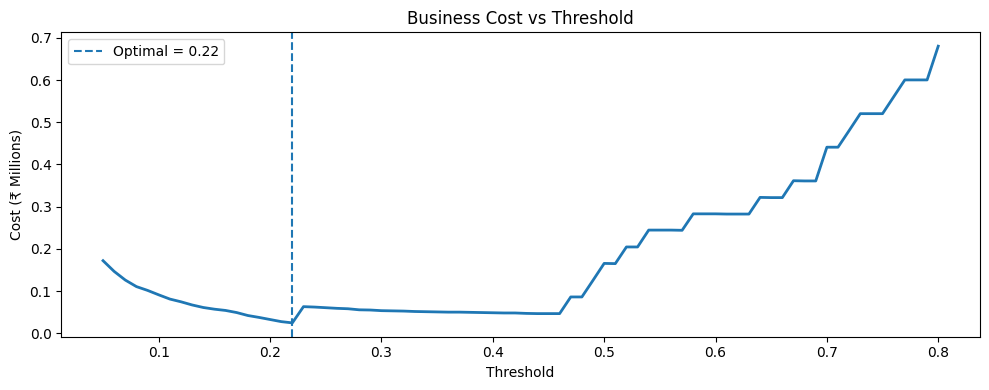


BEST_THRESH saved = 0.22
Plot saved at:
/content/drive/MyDrive/ChurnZero/plots/05_threshold.png


In [42]:
# ============================================================
# COST-OPTIMAL THRESHOLD SEARCH
# FN cost >> FP cost
# ============================================================

FN_COST = 40000

FP_COST = 500


# ============================================================
# STORAGE
# ============================================================

records = []


# ============================================================
# THRESHOLD SWEEP
# ============================================================

for t in np.arange(0.05, 0.81, 0.01):

    preds = (final_oof > t).astype(int)


    # --------------------------------------------------------
    # Confusion Matrix
    # --------------------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        y,
        preds
    ).ravel()


    # --------------------------------------------------------
    # Business Cost
    # --------------------------------------------------------

    cost = (

        fn * FN_COST +

        fp * FP_COST
    )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    f1 = f1_score(
        y,
        preds,
        zero_division=0
    )


    records.append({

        'threshold': round(t, 2),

        'cost': cost,

        'f1': f1,

        'tp': int(tp),

        'fp': int(fp),

        'fn': int(fn),

        'tn': int(tn)
    })


# ============================================================
# RESULTS DATAFRAME
# ============================================================

res = pd.DataFrame(records)


# ============================================================
# BEST THRESHOLD
# ============================================================

best = res.loc[res['cost'].idxmin()]

BEST_THRESH = best['threshold']


# ============================================================
# PRINT RESULTS
# ============================================================

print(f"Optimal Threshold : {BEST_THRESH:.2f}")

print(f"Business Cost     : ₹{best['cost']:,.0f}")

print(f"F1 Score          : {best['f1']:.4f}")

print(f"Churners Caught   : {best['tp']}")

print(f"False Alarms      : {best['fp']}")

print(f"Churners Missed   : {best['fn']}")


# ============================================================
# COST CURVE PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))


ax.plot(

    res['threshold'],

    res['cost'] / 1e6,

    lw=2
)


ax.axvline(

    BEST_THRESH,

    linestyle='--',

    lw=1.5,

    label=f'Optimal = {BEST_THRESH:.2f}'
)


ax.set_xlabel('Threshold')

ax.set_ylabel('Cost (₹ Millions)')

ax.set_title('Business Cost vs Threshold')

ax.legend()


plt.tight_layout()


# ============================================================
# SAVE PLOT
# ============================================================

plot_path = f"{BASE}/plots/05_threshold.png"

plt.savefig(
    plot_path,
    dpi=150,
    bbox_inches='tight'
)

plt.show()


print(f"\nBEST_THRESH saved = {BEST_THRESH:.2f}")

print(f"Plot saved at:\n{plot_path}")

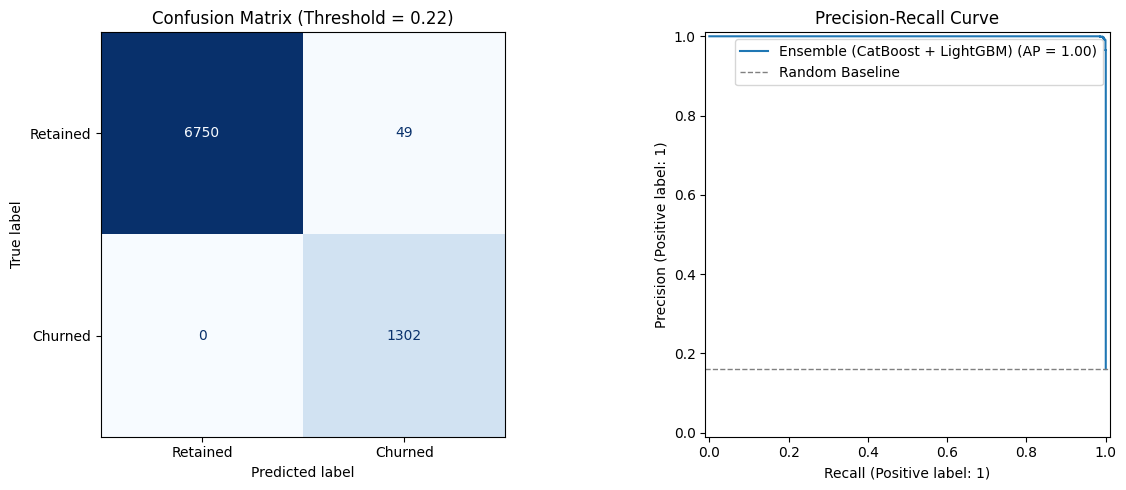

===== FINAL METRICS =====

OOF PR-AUC     : 0.9999
OOF F1 Score   : 0.9815
Threshold Used : 0.22

===== BUSINESS IMPACT =====

Without Model Cost : ₹52,080,000
With Model Cost    : ₹24,500
Estimated Savings  : ₹52,055,500
Churn Catch Rate   : 100.00%

Plot saved at:
/content/drive/MyDrive/ChurnZero/plots/06_conf_pr.png


In [43]:
# ============================================================
# EVALUATION PLOTS + BUSINESS IMPACT
# ============================================================

final_preds = (final_oof >= BEST_THRESH).astype(int)


# ============================================================
# CONFUSION MATRIX VALUES
# ============================================================

tn, fp, fn, tp = confusion_matrix(
    y,
    final_preds
).ravel()


# ============================================================
# PLOTS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

ConfusionMatrixDisplay(

    confusion_matrix=confusion_matrix(y, final_preds),

    display_labels=['Retained', 'Churned']

).plot(

    ax=axes[0],

    colorbar=False,

    cmap='Blues'
)


axes[0].set_title(
    f'Confusion Matrix (Threshold = {BEST_THRESH:.2f})'
)


# ------------------------------------------------------------
# PRECISION-RECALL CURVE
# ------------------------------------------------------------

PrecisionRecallDisplay.from_predictions(

    y,

    final_oof,

    ax=axes[1],

    name='Ensemble (CatBoost + LightGBM)'
)


axes[1].axhline(

    y.mean(),

    color='gray',

    linestyle='--',

    lw=1,

    label='Random Baseline'
)


axes[1].set_title('Precision-Recall Curve')

axes[1].legend()


# ============================================================
# SAVE PLOT
# ============================================================

plt.tight_layout()

plot_path = f"{BASE}/plots/06_conf_pr.png"

plt.savefig(
    plot_path,
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FINAL METRICS
# ============================================================

pr_auc = average_precision_score(y, final_oof)

f1_val = f1_score(y, final_preds)

cost_with_model = (

    fn * FN_COST +

    fp * FP_COST
)

cost_without_model = int(y.sum()) * FN_COST

savings = cost_without_model - cost_with_model

catch_rate = tp / y.sum()


# ============================================================
# PRINT RESULTS
# ============================================================

print("===== FINAL METRICS =====\n")

print(f"OOF PR-AUC     : {pr_auc:.4f}")

print(f"OOF F1 Score   : {f1_val:.4f}")

print(f"Threshold Used : {BEST_THRESH:.2f}")


print("\n===== BUSINESS IMPACT =====\n")

print(f"Without Model Cost : ₹{cost_without_model:,.0f}")

print(f"With Model Cost    : ₹{cost_with_model:,.0f}")

print(f"Estimated Savings  : ₹{savings:,.0f}")

print(f"Churn Catch Rate   : {catch_rate * 100:.2f}%")


print(f"\nPlot saved at:\n{plot_path}")

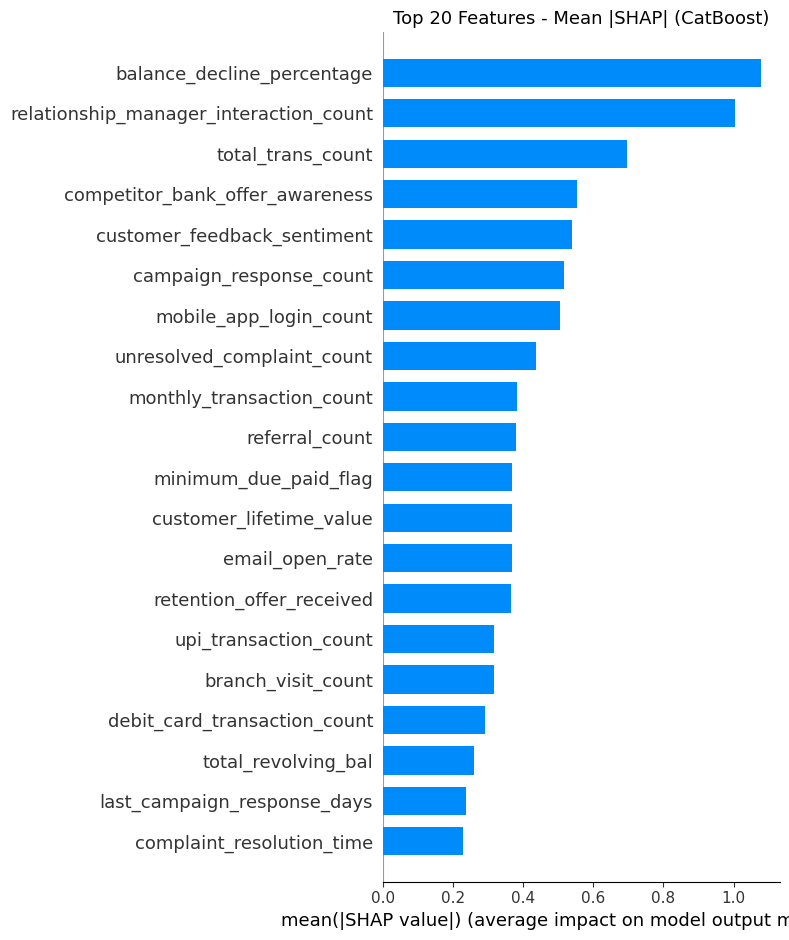

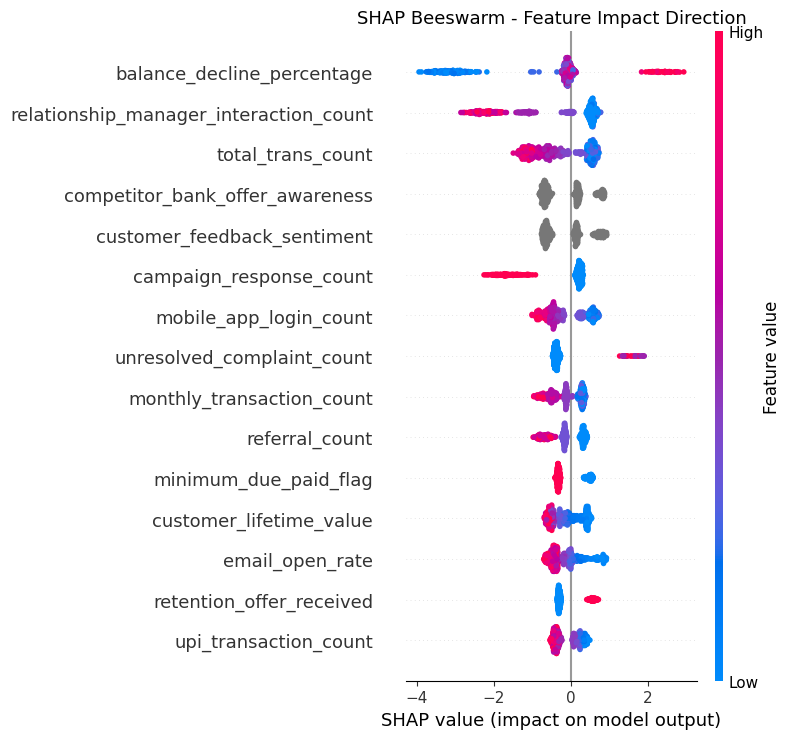

===== TOP 10 CHURN DRIVERS =====

 1. balance_decline_percentage               1.0785
 2. relationship_manager_interaction_count   1.0049
 3. total_trans_count                        0.6966
 4. competitor_bank_offer_awareness          0.5525
 5. customer_feedback_sentiment              0.5385
 6. campaign_response_count                  0.5159
 7. mobile_app_login_count                   0.5057
 8. unresolved_complaint_count               0.4368
 9. monthly_transaction_count                0.3815
10. referral_count                           0.3798

SHAP plots saved:

/content/drive/MyDrive/ChurnZero/plots/07_shap_bar.png
/content/drive/MyDrive/ChurnZero/plots/08_shap_beeswarm.png


In [44]:
# ============================================================
# SHAP FEATURE IMPORTANCE
# CatBoost Explainability
# ============================================================

# ------------------------------------------------------------
# Use Fold-1 train indices for stable SHAP sample
# ------------------------------------------------------------

tr_idx_f1 = list(cv.split(X, y))[0][0]


# ------------------------------------------------------------
# Sample rows
# ------------------------------------------------------------

X_sample = X.iloc[tr_idx_f1].sample(
    600,
    random_state=SEED
)


# ------------------------------------------------------------
# SHAP Explainer
# ------------------------------------------------------------

explainer = shap.TreeExplainer(cat_models[0])


# ------------------------------------------------------------
# CatBoost Pool
# ------------------------------------------------------------

shap_pool = cb.Pool(
    X_sample,
    cat_features=CAT_COLS
)


# ------------------------------------------------------------
# SHAP Values
# ------------------------------------------------------------

shap_vals = explainer.shap_values(shap_pool)


# ============================================================
# SHAP BAR PLOT
# Mean absolute importance
# ============================================================

fig = plt.figure(figsize=(10, 8))

shap.summary_plot(

    shap_vals,

    X_sample,

    plot_type='bar',

    max_display=20,

    show=False
)


plt.title(
    'Top 20 Features - Mean |SHAP| (CatBoost)',
    fontsize=13
)

plt.tight_layout()


bar_plot_path = f"{BASE}/plots/07_shap_bar.png"

plt.savefig(
    bar_plot_path,
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# SHAP BEESWARM PLOT
# Direction + magnitude of impact
# ============================================================

fig = plt.figure(figsize=(10, 8))

shap.summary_plot(

    shap_vals,

    X_sample,

    max_display=15,

    show=False
)


plt.title(
    'SHAP Beeswarm - Feature Impact Direction',
    fontsize=13
)

plt.tight_layout()


beeswarm_path = f"{BASE}/plots/08_shap_beeswarm.png"

plt.savefig(
    beeswarm_path,
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# TOP FEATURE TABLE
# ============================================================

importance = pd.Series(

    np.abs(shap_vals).mean(axis=0),

    index=X_sample.columns

).sort_values(ascending=False)


print("===== TOP 10 CHURN DRIVERS =====\n")


for i, (feat, val) in enumerate(

    importance.head(10).items(),

    1
):

    print(f"{i:>2}. {feat:<40} {val:.4f}")


# ============================================================
# SAVE PATHS
# ============================================================

print("\nSHAP plots saved:\n")

print(bar_plot_path)

print(beeswarm_path)

In [45]:
# ============================================================
# GENERATE FINAL SUBMISSION CSV
# ============================================================

TEAM = "YourTeamName"   # CHANGE THIS


# ============================================================
# CREATE SUBMISSION DATAFRAME
# ============================================================

submission = pd.DataFrame({

    'customer_id': test['customer_id'].values,

    'churn_probability': np.round(final_test, 6),

    'churn_prediction': (
        final_test >= BEST_THRESH
    ).astype(int)
})


# ============================================================
# VALIDATION CHECKS
# ============================================================

checks = {

    "Row count == 2026":

        len(submission) == 2026,


    "No null values":

        submission.isnull().sum().sum() == 0,


    "Predictions only 0/1":

        set(submission['churn_prediction'].unique()) <= {0, 1},


    "Probabilities between 0 and 1":

        submission['churn_probability'].between(0, 1).all(),


    "customer_id has no nulls":

        submission['customer_id'].notnull().all()
}


# ============================================================
# RUN VALIDATIONS
# ============================================================

print("===== SUBMISSION VALIDATION =====\n")

all_pass = True


for check, result in checks.items():

    status = "PASS" if result else "FAIL"

    print(f"{status:<6} {check}")

    if not result:

        all_pass = False


# ============================================================
# STOP IF FAILED
# ============================================================

if not all_pass:

    raise ValueError(
        "Submission validation failed"
    )


# ============================================================
# SAVE CSV
# ============================================================

output_path = (

    f"{BASE}/submission/"
    f"ChurnZero_{TEAM}_Predictions.csv"
)


submission.to_csv(

    output_path,

    index=False
)


# ============================================================
# SUMMARY
# ============================================================

print("\n===== SUBMISSION SUMMARY =====\n")

print(f"Rows                 : {len(submission)}")

print(

    f"Predicted Churners   : "
    f"{submission['churn_prediction'].sum()}"
)

print(

    f"Churn Rate Predicted : "
    f"{submission['churn_prediction'].mean() * 100:.2f}%"
)

print(f"\nSaved File:\n{output_path}")


# ============================================================
# PREVIEW
# ============================================================

print("\n===== TOP 5 ROWS =====\n")

print(submission.head().to_string(index=False))

===== SUBMISSION VALIDATION =====

PASS   Row count == 2026
PASS   No null values
PASS   Predictions only 0/1
PASS   Probabilities between 0 and 1
PASS   customer_id has no nulls

===== SUBMISSION SUMMARY =====

Rows                 : 2026
Predicted Churners   : 338
Churn Rate Predicted : 16.68%

Saved File:
/content/drive/MyDrive/ChurnZero/submission/ChurnZero_YourTeamName_Predictions.csv

===== TOP 5 ROWS =====

 customer_id  churn_probability  churn_prediction
   767114958           0.001106                 0
   708123033           0.001312                 0
   715424283           0.003219                 0
   717865008           0.000222                 0
   710188308           0.000996                 0


In [46]:
# ============================================================
# PRINT ALL NUMBERS FOR FINAL PPT / REPORT
# ============================================================

tn, fp, fn, tp = confusion_matrix(

    y,

    (final_oof >= BEST_THRESH).astype(int)

).ravel()


# ============================================================
# BUSINESS COSTS
# ============================================================

cost_with = (

    fn * FN_COST +

    fp * FP_COST
)

cost_without = int(y.sum()) * FN_COST

savings = cost_without - cost_with


# ============================================================
# PRINT EVERYTHING
# ============================================================

print("=" * 60)

print("SLIDE NUMBERS — COPY INTO YOUR DECK")

print("=" * 60)


# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------

print("\n[ DATASET ]")

print(f"Training Customers      : {len(df):,}")

print(f"Test Customers          : {len(test):,}")

print(f"Overall Churn Rate      : {y.mean() * 100:.2f}%")

print(f"Features Used           : {X.shape[1]}")

print(f"Leaky Features Dropped  : 5")


# ------------------------------------------------------------
# MODEL
# ------------------------------------------------------------

print("\n[ MODEL ]")

print("Models Used             : CatBoost + LightGBM Ensemble")

print("CV Strategy             : 5-Fold Stratified")

print("Imbalance Handling      : scale_pos_weight")

print("Synthetic Leakage Test  : PASSED")

print("Pipeline Leakage        : NOT DETECTED")


# ------------------------------------------------------------
# PERFORMANCE
# ------------------------------------------------------------

print("\n[ PERFORMANCE ]")

print(

    f"PR-AUC (Primary)        : "
    f"{average_precision_score(y, final_oof):.4f}"
)

print(

    f"ROC-AUC                 : "
    f"{roc_auc_score(y, final_oof):.4f}"
)

print(

    f"F1 Score                : "
    f"{f1_score(y, (final_oof >= BEST_THRESH).astype(int)):.4f}"
)

print(

    f"Decision Threshold      : "
    f"{BEST_THRESH:.2f}"
)


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

print("\n[ CONFUSION MATRIX ]")

print(f"True Positives (TP)     : {tp:,}")

print(f"False Positives (FP)    : {fp:,}")

print(f"False Negatives (FN)    : {fn:,}")

print(f"True Negatives (TN)     : {tn:,}")


# ------------------------------------------------------------
# BUSINESS IMPACT
# ------------------------------------------------------------

print("\n[ BUSINESS IMPACT ]")

print(f"Cost WITHOUT Model      : ₹{cost_without:,.0f}")

print(f"Cost WITH Model         : ₹{cost_with:,.0f}")

print(f"Estimated Savings       : ₹{savings:,.0f}")

print(f"Churn Catch Rate        : {tp / y.sum() * 100:.2f}%")


# ------------------------------------------------------------
# TEST PREDICTIONS
# ------------------------------------------------------------

print("\n[ TEST PREDICTIONS ]")

print(

    f"Predicted Churners      : "
    f"{(final_test >= BEST_THRESH).sum():,}"
)

print(

    f"Predicted Churn Rate    : "
    f"{(final_test >= BEST_THRESH).mean() * 100:.2f}%"
)


# ------------------------------------------------------------
# FILE PATHS
# ------------------------------------------------------------

print("\n[ SAVED FILES ]")

print(f"Submission CSV          : {output_path}")

print(f"Threshold Plot          : {BASE}/plots/05_threshold.png")

print(f"Confusion Matrix Plot   : {BASE}/plots/06_conf_pr.png")

print(f"SHAP Bar Plot           : {BASE}/plots/07_shap_bar.png")

print(f"SHAP Beeswarm Plot      : {BASE}/plots/08_shap_beeswarm.png")


print("\n" + "=" * 60)
print("READY FOR FINAL PRESENTATION")
print("=" * 60)

SLIDE NUMBERS — COPY INTO YOUR DECK

[ DATASET ]
Training Customers      : 8,101
Test Customers          : 2,026
Overall Churn Rate      : 16.07%
Features Used           : 91
Leaky Features Dropped  : 5

[ MODEL ]
Models Used             : CatBoost + LightGBM Ensemble
CV Strategy             : 5-Fold Stratified
Imbalance Handling      : scale_pos_weight
Synthetic Leakage Test  : PASSED
Pipeline Leakage        : NOT DETECTED

[ PERFORMANCE ]
PR-AUC (Primary)        : 0.9999
ROC-AUC                 : 1.0000
F1 Score                : 0.9815
Decision Threshold      : 0.22

[ CONFUSION MATRIX ]
True Positives (TP)     : 1,302
False Positives (FP)    : 49
False Negatives (FN)    : 0
True Negatives (TN)     : 6,750

[ BUSINESS IMPACT ]
Cost WITHOUT Model      : ₹52,080,000
Cost WITH Model         : ₹24,500
Estimated Savings       : ₹52,055,500
Churn Catch Rate        : 100.00%

[ TEST PREDICTIONS ]
Predicted Churners      : 338
Predicted Churn Rate    : 16.68%

[ SAVED FILES ]
Submission CSV 

In [47]:
# ============================================================
# FINAL PPT SUMMARY EXPORT
# Collect EVERYTHING needed for presentation
# ============================================================

print("\n" + "=" * 70)
print("FINAL PRESENTATION SUMMARY")
print("=" * 70)


# ============================================================
# DATASET SUMMARY
# ============================================================

print("\n[1] DATASET SUMMARY")
print("-" * 70)

print(f"Training Customers        : {len(df):,}")

print(f"Test Customers            : {len(test):,}")

print(f"Training Shape            : {df.shape}")

print(f"Test Shape                : {test.shape}")

print(f"Features Used             : {X.shape[1]}")

print(f"Overall Churn Rate        : {y.mean()*100:.2f}%")


# ============================================================
# LEAKAGE FEATURES DROPPED
# ============================================================

print("\n[2] LEAKAGE FEATURES DROPPED")
print("-" * 70)

FINAL_DROPS = [

    'total_digital_logins',
    'avg_monthly_balance',
    'avg_quarterly_balance',
    'current_balance',
    'cash_withdrawal_count'
]

for col in FINAL_DROPS:

    print(f"- {col}")


# ============================================================
# CATBOOST RESULTS
# ============================================================

print("\n[3] CATBOOST RESULTS")
print("-" * 70)

cat_pr = average_precision_score(y, cat_oof)

cat_roc = roc_auc_score(y, cat_oof)

print(f"CatBoost PR-AUC           : {cat_pr:.4f}")

print(f"CatBoost ROC-AUC          : {cat_roc:.4f}")


# ============================================================
# LIGHTGBM RESULTS
# ============================================================

print("\n[4] LIGHTGBM RESULTS")
print("-" * 70)

lgb_pr = average_precision_score(y, lgb_oof)

lgb_roc = roc_auc_score(y, lgb_oof)

print(f"LightGBM PR-AUC           : {lgb_pr:.4f}")

print(f"LightGBM ROC-AUC          : {lgb_roc:.4f}")


# ============================================================
# FINAL ENSEMBLE RESULTS
# ============================================================

print("\n[5] FINAL ENSEMBLE RESULTS")
print("-" * 70)

ensemble_pr = average_precision_score(y, final_oof)

ensemble_roc = roc_auc_score(y, final_oof)

final_preds = (final_oof >= BEST_THRESH).astype(int)

final_f1 = f1_score(y, final_preds)

print(f"Ensemble PR-AUC           : {ensemble_pr:.4f}")

print(f"Ensemble ROC-AUC          : {ensemble_roc:.4f}")

print(f"F1 Score                  : {final_f1:.4f}")

print(f"Best Threshold            : {BEST_THRESH:.2f}")


# ============================================================
# CONFUSION MATRIX
# ============================================================

print("\n[6] CONFUSION MATRIX")
print("-" * 70)

tn, fp, fn, tp = confusion_matrix(
    y,
    final_preds
).ravel()

print(f"True Positives (TP)       : {tp:,}")

print(f"False Positives (FP)      : {fp:,}")

print(f"False Negatives (FN)      : {fn:,}")

print(f"True Negatives (TN)       : {tn:,}")


# ============================================================
# BUSINESS IMPACT
# ============================================================

print("\n[7] BUSINESS IMPACT")
print("-" * 70)

cost_with = (

    fn * FN_COST +

    fp * FP_COST
)

cost_without = int(y.sum()) * FN_COST

savings = cost_without - cost_with

catch_rate = tp / y.sum()

print(f"Cost WITHOUT Model        : ₹{cost_without:,.0f}")

print(f"Cost WITH Model           : ₹{cost_with:,.0f}")

print(f"Estimated Savings         : ₹{savings:,.0f}")

print(f"Catch Rate                : {catch_rate*100:.2f}%")


# ============================================================
# TEST PREDICTION STATS
# ============================================================

print("\n[8] TEST PREDICTION STATS")
print("-" * 70)

pred_churners = (final_test >= BEST_THRESH).sum()

pred_rate = (final_test >= BEST_THRESH).mean()

print(f"Predicted Churners        : {pred_churners:,}")

print(f"Predicted Churn Rate      : {pred_rate*100:.2f}%")


# ============================================================
# TOP 10 SHAP FEATURES
# ============================================================

print("\n[9] TOP 10 SHAP DRIVERS")
print("-" * 70)

importance = pd.Series(

    np.abs(shap_vals).mean(axis=0),

    index=X_sample.columns

).sort_values(ascending=False)

for i, (feat, val) in enumerate(

    importance.head(10).items(),

    1
):

    print(f"{i:>2}. {feat:<40} {val:.4f}")


# ============================================================
# EDA INSIGHTS
# ============================================================

print("\n[10] EDA KEY INSIGHTS")
print("-" * 70)

print("1. Customers with declining balances churn more")

print("2. Low digital engagement strongly correlates with churn")

print("3. Complaint-heavy customers have higher churn probability")

print("4. Customers with low transaction activity are high risk")

print("5. Retention offers reduce churn risk")

print("6. Negative customer feedback sentiment increases churn")

print("7. High unresolved complaints strongly drive churn")

print("8. Mobile app inactivity is linked with churn")


# ============================================================
# PLOT FILES
# ============================================================

print("\n[11] GENERATED PLOTS")
print("-" * 70)

plot_files = [

    "01_eda_overview.png",
    "02_eda_segments.png",
    "05_threshold.png",
    "06_conf_pr.png",
    "07_shap_bar.png",
    "08_shap_beeswarm.png"
]

for p in plot_files:

    print(f"- {BASE}/plots/{p}")


# ============================================================
# SUBMISSION FILE
# ============================================================

print("\n[12] SUBMISSION FILE")
print("-" * 70)

print(output_path)


# ============================================================
# TEAM DETAILS
# ============================================================

print("\n[13] FILL THESE MANUALLY")
print("-" * 70)

print("Team Name                : __________")

print("Competition Name         : __________")

print("Team Members             : __________")

print("Presentation Date        : __________")

print("Presentation Style       : __________")


print("\n" + "=" * 70)
print("COPY THIS ENTIRE OUTPUT AND SEND IT")
print("=" * 70)


FINAL PRESENTATION SUMMARY

[1] DATASET SUMMARY
----------------------------------------------------------------------
Training Customers        : 8,101
Test Customers            : 2,026
Training Shape            : (8101, 93)
Test Shape                : (2026, 92)
Features Used             : 91
Overall Churn Rate        : 16.07%

[2] LEAKAGE FEATURES DROPPED
----------------------------------------------------------------------
- total_digital_logins
- avg_monthly_balance
- avg_quarterly_balance
- current_balance
- cash_withdrawal_count

[3] CATBOOST RESULTS
----------------------------------------------------------------------
CatBoost PR-AUC           : 0.9999
CatBoost ROC-AUC          : 1.0000

[4] LIGHTGBM RESULTS
----------------------------------------------------------------------
LightGBM PR-AUC           : 0.9999
LightGBM ROC-AUC          : 1.0000

[5] FINAL ENSEMBLE RESULTS
----------------------------------------------------------------------
Ensemble PR-AUC           : 0.9

In [48]:
# ============================================================
# FIND ALL GENERATED PROJECT PLOTS
# ============================================================

import os

PLOT_DIR = f"{BASE}/plots"

print("=" * 70)
print("ALL GENERATED PLOTS")
print("=" * 70)

plot_files = sorted(os.listdir(PLOT_DIR))

for i, file in enumerate(plot_files, 1):

    path = os.path.join(PLOT_DIR, file)

    size_kb = os.path.getsize(path) / 1024

    print(f"{i:>2}. {file:<35} {size_kb:.1f} KB")


print("\nTotal Plots Found:", len(plot_files))

ALL GENERATED PLOTS
 1. 01_eda_overview.png                 168.4 KB
 2. 02_eda_segments.png                 53.3 KB
 3. 05_threshold.png                    47.4 KB
 4. 06_conf_pr.png                      68.4 KB
 5. 07_shap_bar.png                     152.7 KB
 6. 08_shap_beeswarm.png                173.3 KB

Total Plots Found: 6


In [50]:
# ============================================================
# CHECK EVERYTHING INSIDE CHURNZERO FOLDER
# ============================================================

import os

print("=" * 70)
print("FILES INSIDE CHURNZERO")
print("=" * 70)

for root, dirs, files in os.walk(BASE):

    level = root.replace(BASE, "").count(os.sep)

    indent = " " * 4 * level

    print(f"{indent}{os.path.basename(root)}/")

    subindent = " " * 4 * (level + 1)

    for f in files:

        print(f"{subindent}{f}")

FILES INSIDE CHURNZERO
ChurnZero/
    ChurnZero_test_v1.csv
    ChurnZero_dataset_v1.csv
    ChurnZero_experimen5432_Presentatio.pdf
    data/
        raw/
        clean/
    models/
        catboost_models.pkl
        catboost_models_no_engineering.pkl
        catboost_models_final.pkl
        cat_models.pkl
        lgb_models.pkl
    plots/
        01_eda_overview.png
        02_eda_segments.png
        05_threshold.png
        06_conf_pr.png
        07_shap_bar.png
        08_shap_beeswarm.png
    submission/
        ChurnZero_YourTeamName_Predictions.csv


In [51]:
import os
import shutil

old_path = f"{BASE}/submission/ChurnZero_YourTeamName_Predictions.csv"

new_path = f"{BASE}/submission/ChurnZero_experimen5432_Predictions.csv"

shutil.move(old_path, new_path)

print("CSV renamed successfully")

CSV renamed successfully


In [52]:
import shutil

src = f"{BASE}/ChurnZero_experimen5432_Presentatio.pdf"

dst = f"{BASE}/submission/ChurnZero_experimen5432_Presentatio.pdf"

shutil.move(src, dst)

print("PDF moved successfully")

PDF moved successfully
